# 1. Project Overview

Notebook ini isinya EDA (exploratory data analysis) lengkap buat file `fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv` — data titik panas (hotspot) dari FIRMS di area Kalimantan, rentang 2024–2026. Tujuannya bukan cuma "liat-liat data doang", tapi bener-bener ngecek: kualitas datanya gimana, pola waktunya kayak apa (musiman?), sebarannya di mana aja, intensitas apinya gimana, seberapa bisa dipercaya kolom `confidence`-nya, ada efek dari sensor/satelit gak, sampe akhirnya nilai kelayakan tiap variabel buat dipakai di scoring/risk model nanti.

**Penting buat dicatat dari awal:** notebook ini *murni* EDA dari file mentahnya doang — gak ada dataset eksternal, gak ada boundary provinsi, gak ada spatial join, apalagi model ML. Semuanya masih raw analysis. Terus, karena data 2026 kemungkinan besar masih parsial (belum penuh setahun), tiap kali bandingin 2026 sama tahun lain, itu harus hati-hati banget — bandinginnya musti pakai periode yang durasinya setara (apple-to-apple), bukan total mentah-mentahan.

Pertanyaan besar yang mau dijawab di sini:
- Datanya reliable gak, ada masalah kualitas gak?
- Cakupan waktunya lengkap atau bolong-bolong?
- Ada pola musiman yang jelas gak?
- Sebaran geografisnya kekonsentrasi di mana?
- Intensitas apinya bervariasi seberapa jauh?
- Kolom `confidence` itu beneran berguna atau cuma noise?
- Variabel-variabel yang ada ini cocok gak buat dipakai scoring ke depannya?


# 2. Setup & Imports

Bagian ini cuma buat import semua library yang dibutuhin — pandas/numpy buat olah data, matplotlib/seaborn buat visualisasi, plus setting display biar output di notebook rapi. Semua hasil plot & tabel nanti disimpen otomatis ke folder `outputs/figures` dan `outputs/tables`, gak nyebar ke mana-mana.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')

DATA = Path('data/fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv')
if not DATA.exists():
    DATA = Path('fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv')
FIGURES_DIR = Path('outputs/figures')
TABLES_DIR = Path('outputs/tables')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# 3. Data Loading

Load CSV mentahnya apa adanya — gak nambahin data pendukung apapun di tahap ini. Yang dilakuin cuma normalisasi nama kolom (lowercase, strip spasi, ganti spasi jadi underscore) biar enak dipanggil di kode-kode selanjutnya. Isi datanya sendiri belum diubah sama sekali.

In [2]:
# Load the raw dataset without dropping rows or modifying values.
df = pd.read_csv(DATA)

print('First 5 rows:')
display(df.head())
print('Dataset shape:', df.shape)
print('Column names:')
display(pd.Index(df.columns, name='column_name').to_frame())
print('Data types:')
display(df.dtypes.to_frame('data_type'))
print('Basic dataset information:')
df.info()

requested_variables = ['latitude', 'longitude', 'acq_date', 'acq_time', 'brightness', 'bright_t31', 'frp', 'confidence', 'daynight', 'satellite', 'instrument', 'version', 'scan', 'track', 'type']
available_variables = [column for column in requested_variables if column in df.columns.str.lower()]
column_lookup = {column.lower(): column for column in df.columns}
variable_inspection = pd.DataFrame({
    'requested_variable': requested_variables,
    'available_column': [column_lookup.get(variable) for variable in requested_variables],
    'status': ['available' if variable in column_lookup else 'not found' for variable in requested_variables]
})
print('Requested FIRMS variable inspection:')
display(variable_inspection)

# Keep the original column names and values intact during initial inspection.
display(df[[column_lookup[variable] for variable in requested_variables if variable in column_lookup]].head())

First 5 rows:


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-2.069,110.915,342.890,0.520,0.410,2024-08-01,545,N20,VIIRS,n,2,295.590,32.350,D,0
1,-2.066,110.914,335.580,0.520,0.410,2024-08-01,545,N20,VIIRS,n,2,298.050,60.850,D,0
2,-1.532,114.348,332.340,0.390,0.360,2024-08-01,545,N20,VIIRS,n,2,296.860,2.770,D,0
3,-0.879,115.037,334.210,0.380,0.360,2024-08-01,545,N20,VIIRS,n,2,296.660,2.610,D,0
4,-0.875,115.037,342.370,0.380,0.360,2024-08-01,545,N20,VIIRS,n,2,298.420,14.550,D,0


Dataset shape: (61583, 15)
Column names:


,column_name
column_name,
latitude,latitude
longitude,longitude
brightness,brightness
scan,scan
track,track
acq_date,acq_date
acq_time,acq_time
satellite,satellite
instrument,instrument


Data types:


,data_type
latitude,float64
longitude,float64
brightness,float64
scan,float64
track,float64
acq_date,str
acq_time,int64
satellite,str
instrument,str
confidence,str


Basic dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 61583 entries, 0 to 61582
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    61583 non-null  float64
 1   longitude   61583 non-null  float64
 2   brightness  61583 non-null  float64
 3   scan        61583 non-null  float64
 4   track       61583 non-null  float64
 5   acq_date    61583 non-null  str    
 6   acq_time    61583 non-null  int64  
 7   satellite   61583 non-null  str    
 8   instrument  61583 non-null  str    
 9   confidence  61583 non-null  str    
 10  version     61583 non-null  int64  
 11  bright_t31  61583 non-null  float64
 12  frp         61583 non-null  float64
 13  daynight    61583 non-null  str    
 14  type        61583 non-null  int64  
dtypes: float64(7), int64(3), str(5)
memory usage: 7.0 MB
Requested FIRMS variable inspection:


,requested_variable,available_column,status
0,latitude,latitude,available
1,longitude,longitude,available
2,acq_date,acq_date,available
3,acq_time,acq_time,available
4,brightness,brightness,available
5,bright_t31,bright_t31,available
6,frp,frp,available
7,confidence,confidence,available
8,daynight,daynight,available
9,satellite,satellite,available


,latitude,longitude,acq_date,acq_time,brightness,bright_t31,frp,confidence,daynight,satellite,instrument,version,scan,track,type
0,-2.069,110.915,2024-08-01,545,342.890,295.590,32.350,n,D,N20,VIIRS,2,0.520,0.410,0
1,-2.066,110.914,2024-08-01,545,335.580,298.050,60.850,n,D,N20,VIIRS,2,0.520,0.410,0
2,-1.532,114.348,2024-08-01,545,332.340,296.860,2.770,n,D,N20,VIIRS,2,0.390,0.360,0
3,-0.879,115.037,2024-08-01,545,334.210,296.660,2.610,n,D,N20,VIIRS,2,0.380,0.360,0
4,-0.875,115.037,2024-08-01,545,342.370,298.420,14.550,n,D,N20,VIIRS,2,0.380,0.360,0


# 4. Dataset Overview

Ngecek gambaran umum dulu: berapa baris, berapa kolom, tipe data tiap kolom, statistik deskriptif (mean, median, dst), sama struktur nilai unik per kolom. Ini jadi baseline sebelum masuk ke analisis yang lebih dalam. Nama kolom yang udah distandarisasi (lowercase + underscore) baru dipakai *setelah* inspeksi awal di atas — jadi urutannya: liat raw dulu, baru normalisasi.

In [3]:
df.columns = [column.strip().lower().replace(' ', '_') for column in df.columns]
FIG = FIGURES_DIR
TAB = TABLES_DIR
date_column = next((column for column in df.columns if 'date' in column or 'acq' in column), None)
overview_datetime = pd.to_datetime(df[date_column], errors='coerce') if date_column else pd.Series(dtype='datetime64[ns]')
summary = pd.DataFrame({'Metric':['Total Rows','Total Columns','Earliest Date','Latest Date','Duplicate Rows','Total Missing Values'], 'Value':[len(df),df.shape[1],overview_datetime.min(),overview_datetime.max(),int(df.duplicated().sum()),int(df.isna().sum().sum())]})
display(summary)
df.info()
display(df.describe(include='all').T)
missing_summary = pd.DataFrame({'Column name':df.columns,'Missing count':df.isna().sum().values,'Missing percentage':(df.isna().mean().values*100).round(2)}).sort_values('Missing count',ascending=False)
display(missing_summary)
summary.to_csv(TAB/'dataset_summary.csv',index=False)
missing_summary.to_csv(TAB/'missing_value_summary.csv',index=False)

,Metric,Value
0,Total Rows,61583
1,Total Columns,15
2,Earliest Date,2024-08-01 00:00:00
3,Latest Date,2026-05-31 00:00:00
4,Duplicate Rows,0
5,Total Missing Values,0


<class 'pandas.DataFrame'>
RangeIndex: 61583 entries, 0 to 61582
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    61583 non-null  float64
 1   longitude   61583 non-null  float64
 2   brightness  61583 non-null  float64
 3   scan        61583 non-null  float64
 4   track       61583 non-null  float64
 5   acq_date    61583 non-null  str    
 6   acq_time    61583 non-null  int64  
 7   satellite   61583 non-null  str    
 8   instrument  61583 non-null  str    
 9   confidence  61583 non-null  str    
 10  version     61583 non-null  int64  
 11  bright_t31  61583 non-null  float64
 12  frp         61583 non-null  float64
 13  daynight    61583 non-null  str    
 14  type        61583 non-null  int64  
dtypes: float64(7), int64(3), str(5)
memory usage: 7.0 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
latitude,"61,583.000",NaN,NaN,NaN,-0.171,1.437,-4.173,-1.053,-0.017,0.696,4.351
longitude,"61,583.000",NaN,NaN,NaN,112.666,2.845,108.684,110.415,111.569,115.238,119.499
brightness,"61,583.000",NaN,NaN,NaN,335.870,13.677,207.930,331.290,335.860,342.220,367.000
scan,"61,583.000",NaN,NaN,NaN,0.460,0.087,0.320,0.390,0.440,0.510,0.800
track,"61,583.000",NaN,NaN,NaN,0.484,0.109,0.360,0.390,0.460,0.560,0.780
acq_date,61583,629,2024-09-03,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acq_time,"61,583.000",NaN,NaN,NaN,703.356,370.175,434.000,538.000,605.000,630.000,"1,901.000"
satellite,61583,1,N20,61583,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instrument,61583,1,VIIRS,61583,NaN,NaN,NaN,NaN,NaN,NaN,NaN
confidence,61583,3,n,57315,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Column name,Missing count,Missing percentage
0,latitude,0,0.000
1,longitude,0,0.000
2,brightness,0,0.000
3,scan,0,0.000
4,track,0,0.000
5,acq_date,0,0.000
6,acq_time,0,0.000
7,satellite,0,0.000
8,instrument,0,0.000
9,confidence,0,0.000


# 5. Data Quality & Validation

Sekarang masuk ke pengecekan kualitas data secara menyeluruh: parsing tanggal bener gak, ada duplikat gak, missing value di mana aja, range numerik masuk akal gak, koordinat valid gak, kategori konsisten gak, sama ID-nya unik gak. Semua pengecekan di sini sifatnya deskriptif — cuma buat *ngasih tau* kondisi datanya, bukan buat diam-diam ngehapus baris. Jadi kalau ada anomali, dicatet aja, bukan langsung di-drop.

In [4]:
date_candidates = [c for c in df.columns if 'acq' in c or 'date' in c or 'time' in c]
date_col = next((c for c in date_candidates if 'date' in c or 'acq' in c), None)
if date_col: df['_datetime'] = pd.to_datetime(df[date_col], errors='coerce')
numeric = df.select_dtypes(include=np.number).columns.tolist()
quality = {'rows':len(df), 'exact_duplicate_rows':int(df.duplicated().sum()), 'date_column':date_col, 'unparseable_dates':int(df['_datetime'].isna().sum()) if date_col else None}
for key, terms in {'latitude':['latitude','lat'], 'longitude':['longitude','lon'], 'confidence':['confidence','conf'], 'frp':['frp','power'], 'scan':['scan'], 'track':['track']}.items():
    hit = next((c for c in df.columns if any(t in c for t in terms)), None)
    if hit: quality[key] = hit
display(pd.Series(quality, name='value'))
for label, col in [('latitude',quality.get('latitude')),('longitude',quality.get('longitude')),('confidence',quality.get('confidence')),('frp',quality.get('frp'))]:
    if col and pd.api.types.is_numeric_dtype(df[col]): display(pd.DataFrame({'metric':['min','median','max','missing'], 'value':[df[col].min(),df[col].median(),df[col].max(),df[col].isna().sum()]}).assign(variable=label))
    elif col: display(pd.DataFrame({'metric':['unique_values','missing'], 'value':[df[col].nunique(dropna=True),df[col].isna().sum()]}).assign(variable=label))
display(missing_summary.sort_values('Missing count', ascending=False))
display(Markdown('Validation interpretation: ' + str(quality['exact_duplicate_rows']) + ' exact duplicate rows were detected and ' + str(quality.get('unparseable_dates', 'not assessed')) + ' dates were unparseable.'))

rows                         61583
exact_duplicate_rows             0
date_column               acq_date
unparseable_dates                0
latitude                  latitude
longitude                longitude
confidence              confidence
frp                            frp
scan                          scan
track                        track
Name: value, dtype: object

,metric,value,variable
0,min,-4.173,latitude
1,median,-0.017,latitude
2,max,4.351,latitude
3,missing,0.000,latitude


,metric,value,variable
0,min,108.684,longitude
1,median,111.569,longitude
2,max,119.499,longitude
3,missing,0.000,longitude


,metric,value,variable
0,unique_values,3,confidence
1,missing,0,confidence


,metric,value,variable
0,min,0.090,frp
1,median,6.140,frp
2,max,954.790,frp
3,missing,0.000,frp


,Column name,Missing count,Missing percentage
0,latitude,0,0.000
1,longitude,0,0.000
2,brightness,0,0.000
3,scan,0,0.000
4,track,0,0.000
5,acq_date,0,0.000
6,acq_time,0,0.000
7,satellite,0,0.000
8,instrument,0,0.000
9,confidence,0,0.000


Validation interpretation: 0 exact duplicate rows were detected and 0 dates were unparseable.

In [5]:
focus_columns = [column for column in ['latitude','longitude','acq_date','frp','confidence','daynight'] if column in df.columns]
display(missing_summary[missing_summary['Column name'].isin(focus_columns)])
duplicate_keys = [column for column in ['latitude','longitude','acq_date','acq_time','satellite'] if column in df.columns]
if duplicate_keys:
    potential_duplicate_groups = df.groupby(duplicate_keys, dropna=False).size().reset_index(name='records')
    potential_duplicate_groups = potential_duplicate_groups[potential_duplicate_groups['records'] > 1].sort_values('records', ascending=False)
    potential_duplicate_rows = int(potential_duplicate_groups['records'].sum())
    display(pd.DataFrame({'Metric':['Exact duplicate rows','Potential duplicate groups','Rows in potential duplicate groups'], 'Value':[int(df.duplicated().sum()),len(potential_duplicate_groups),potential_duplicate_rows]}))
    display(potential_duplicate_groups.head(20))
    potential_duplicate_groups.to_csv(TAB/'potential_duplicate_groups.csv', index=False)
    display(Markdown('Potential duplicate detections are repeated observations sharing the selected key fields; they are not automatically assumed to be errors.'))
else:
    display(Markdown('The requested potential-duplicate key columns were not available.'))

,Column name,Missing count,Missing percentage
0,latitude,0,0.000
1,longitude,0,0.000
5,acq_date,0,0.000
9,confidence,0,0.000
12,frp,0,0.000
13,daynight,0,0.000


,Metric,Value
0,Exact duplicate rows,0
1,Potential duplicate groups,0
2,Rows in potential duplicate groups,0


,latitude,longitude,acq_date,acq_time,satellite,records


Potential duplicate detections are repeated observations sharing the selected key fields; they are not automatically assumed to be errors.

## 5.3 Geographic Coordinate Validation

Validasi range latitude & longitude — cek apakah ada koordinat yang gak mungkin (misalnya di luar -90 s.d. 90 buat lat) atau mencurigakan, terus liat apakah footprint koordinatnya secara umum masuk akal buat area Kalimantan. Di tahap ini belum ada assignment ke provinsi atau join ke boundary manapun — itu baru dicek lebih detail di bagian 8.4 pakai geopandas.

In [6]:
latitude_column = quality.get('latitude')
longitude_column = quality.get('longitude')
coordinate_checks = []
for coordinate_name, coordinate_column, lower_bound, upper_bound in [('latitude', latitude_column, -90, 90), ('longitude', longitude_column, -180, 180)]:
    if coordinate_column:
        values = pd.to_numeric(df[coordinate_column], errors='coerce')
        coordinate_checks.append({'coordinate':coordinate_name,'column':coordinate_column,'minimum':values.min(),'maximum':values.max(),'missing':int(values.isna().sum()),'impossible_values':int(((values < lower_bound) | (values > upper_bound)).sum())})
coordinate_check_table = pd.DataFrame(coordinate_checks)
display(coordinate_check_table)
if latitude_column and longitude_column:
    suspicious_coordinates = df[(pd.to_numeric(df[latitude_column],errors='coerce').abs()>90) | (pd.to_numeric(df[longitude_column],errors='coerce').abs()>180) | df[latitude_column].isna() | df[longitude_column].isna()]
    print('Suspicious coordinate records:', len(suspicious_coordinates))
    display(suspicious_coordinates.head(20))
    valid_coordinates = df[[latitude_column, longitude_column]].apply(pd.to_numeric, errors='coerce').dropna()
    display(Markdown(f'Observed coordinate ranges are latitude **{valid_coordinates[latitude_column].min():.3f} to {valid_coordinates[latitude_column].max():.3f}** and longitude **{valid_coordinates[longitude_column].min():.3f} to {valid_coordinates[longitude_column].max():.3f}**. The footprint is broadly plausible for Kalimantan if it falls within the expected equatorial Southeast Asian range; this is a plausibility check only, not a province validation.'))
coordinate_check_table.to_csv(TAB/'coordinate_validation.csv', index=False)

,coordinate,column,minimum,maximum,missing,impossible_values
0,latitude,latitude,-4.173,4.351,0,0
1,longitude,longitude,108.684,119.499,0,0


Suspicious coordinate records: 0


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,_datetime


Observed coordinate ranges are latitude **-4.173 to 4.351** and longitude **108.684 to 119.499**. The footprint is broadly plausible for Kalimantan if it falls within the expected equatorial Southeast Asian range; this is a plausibility check only, not a province validation.

## 5.4 FRP Validation

FRP (Fire Radiative Power) dicek integritasnya: ada nilai nol/negatif gak, missing berapa persen, dan gimana sebaran nilai ekstremnya. Nilai-nilai ekstrem sengaja **gak dibuang** karena bisa aja itu emang deteksi kebakaran dengan intensitas tinggi beneran — bukan noise/error.

In [7]:
if frp := quality.get('frp'):
    frp_values = pd.to_numeric(df[frp], errors='coerce')
    frp_validation = pd.DataFrame({'Metric':['Minimum FRP','Maximum FRP','Negative values','Zero values','Missing values','99th percentile','99.9th percentile'], 'Value':[frp_values.min(),frp_values.max(),int((frp_values<0).sum()),int((frp_values==0).sum()),int(frp_values.isna().sum()),frp_values.quantile(.99),frp_values.quantile(.999)]})
    display(frp_validation)
    extreme_frp = df[frp_values >= frp_values.quantile(.999)].copy().sort_values(frp, ascending=False)
    print('Extreme FRP observations at or above the 99.9th percentile:', len(extreme_frp))
    display(extreme_frp.head(20))
    frp_validation.to_csv(TAB/'frp_validation.csv', index=False)
    display(Markdown('Extreme FRP observations are reported for investigation and are not automatically removed.'))

,Metric,Value
0,Minimum FRP,0.090
1,Maximum FRP,954.790
2,Negative values,0.000
3,Zero values,0.000
4,Missing values,0.000
5,99th percentile,70.197
6,99.9th percentile,204.220


Extreme FRP observations at or above the 99.9th percentile: 62


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,_datetime
25395,-2.617,114.710,207.930,0.420,0.370,2025-03-08,538,N20,VIIRS,l,2,294.490,954.790,D,0,2025-03-08
25384,-2.869,114.798,207.930,0.420,0.370,2025-03-08,538,N20,VIIRS,l,2,292.960,825.560,D,0,2025-03-08
57696,-1.490,110.142,367.000,0.460,0.390,2026-03-05,555,N20,VIIRS,l,2,336.540,652.450,D,0,2026-03-05
16982,-0.003,116.804,207.930,0.530,0.500,2024-09-17,604,N20,VIIRS,l,2,321.580,550.260,D,0,2024-09-17
16980,-0.008,116.805,367.000,0.530,0.500,2024-09-17,604,N20,VIIRS,l,2,337.410,550.260,D,0,2024-09-17
16977,-0.007,116.810,335.970,0.530,0.500,2024-09-17,604,N20,VIIRS,n,2,305.560,550.260,D,0,2024-09-17
25386,-2.870,114.790,207.930,0.420,0.370,2025-03-08,538,N20,VIIRS,l,2,296.310,470.100,D,0,2025-03-08
25385,-2.870,114.794,207.930,0.420,0.370,2025-03-08,538,N20,VIIRS,l,2,294.570,470.100,D,0,2025-03-08
51181,-1.131,113.882,207.930,0.440,0.380,2025-10-02,539,N20,VIIRS,l,2,298.300,459.700,D,0,2025-10-02
25375,-2.985,114.818,207.930,0.420,0.370,2025-03-08,538,N20,VIIRS,l,2,290.850,445.570,D,0,2025-03-08


Extreme FRP observations are reported for investigation and are not automatically removed.

## 5.5 Categorical Variable Validation

Ngecek distribusi kategori-kategori penting dari FIRMS (kayak `confidence`, `daynight`, `satellite`, dll) — ada kategori yang hilang gak, ada inkonsistensi kapitalisasi/whitespace gak (misal " N " vs "N"), dan ada nilai yang jarang banget muncul (rare value) yang perlu dicurigai gak.

In [8]:
categorical_columns = [column for column in ['confidence','daynight','satellite','instrument','version','type'] if column in df.columns]
categorical_audit_rows = []
for column in categorical_columns:
    values = df[column]
    counts = values.value_counts(dropna=False)
    normalized = values.dropna().astype(str).str.strip().str.lower()
    inconsistent_case = int(normalized.nunique() < values.dropna().astype(str).nunique())
    for category, count in counts.items():
        categorical_audit_rows.append({'column':column,'category':category,'count':int(count),'percentage':round(count/len(df)*100,3),'rare_less_than_1pct':bool(count/len(df)<.01),'missing_category':bool(pd.isna(category)),'case_or_whitespace_variants_possible':inconsistent_case})
categorical_audit = pd.DataFrame(categorical_audit_rows)
display(categorical_audit)
categorical_audit.to_csv(TAB/'categorical_validation.csv', index=False)
display(Markdown('Unexpected categories are assessed relative to the observed values because no external category dictionary was supplied. Rare values and possible capitalization/whitespace variants are documented for review rather than silently recoded.'))

,column,category,count,percentage,rare_less_than_1pct,missing_category,case_or_whitespace_variants_possible
0,confidence,n,57315,93.070,False,False,0
1,confidence,h,2320,3.767,False,False,0
2,confidence,l,1948,3.163,False,False,0
3,daynight,D,54988,89.291,False,False,0
4,daynight,N,6595,10.709,False,False,0
5,satellite,N20,61583,100.000,False,False,0
6,instrument,VIIRS,61583,100.000,False,False,0
7,version,2,61583,100.000,False,False,0
8,type,0,61583,100.000,False,False,0


Unexpected categories are assessed relative to the observed values because no external category dictionary was supplied. Rare values and possible capitalization/whitespace variants are documented for review rather than silently recoded.

# 6. Temporal Coverage

Ngukur rentang tanggal yang kecover di dataset, jumlah record per tahun/bulan, kontinuitas harian, sama ada gap tanggal apa gak. Penting diinget: yang dihitung di sini itu jumlah *observasi/deteksi*, bukan otomatis jumlah kebakaran unik — karena satu titik api bisa aja kedetek berkali-kali di hari/lintasan satelit yang beda.

,metric,value
0,first_observation,2024-08-01 00:00:00
1,last_observation,2026-05-31 00:00:00
2,observed_days,629
3,missing_months,14
4,incomplete_years,[2026]


,year,hotspot_count
0,2024,24884
1,2025,29735
2,2026,6964


,month,hotspot_count
0,1,2151
1,2,948
2,3,2829
3,4,1256
4,5,1396
5,6,682
6,7,7508
7,8,10808
8,9,25987
9,10,6390


,year_month,hotspot_count
0,2024-08,3539
1,2024-09,16911
2,2024-10,3744
3,2024-11,534
4,2024-12,156
5,2025-01,124
6,2025-02,308
7,2025-03,252
8,2025-04,222
9,2025-05,710


,date,hotspot_count
0,2024-08-01,191
1,2024-08-02,5
2,2024-08-03,47
3,2024-08-04,256
4,2024-08-05,287
5,2024-08-06,70
6,2024-08-07,14
7,2024-08-08,31
8,2024-08-09,56
9,2024-08-10,315


**Coverage diagnostics:** 14 year-month combinations have no records, and 40 dates have no detections within the observed span. Years ending before December are flagged as incomplete: **[2026]**.

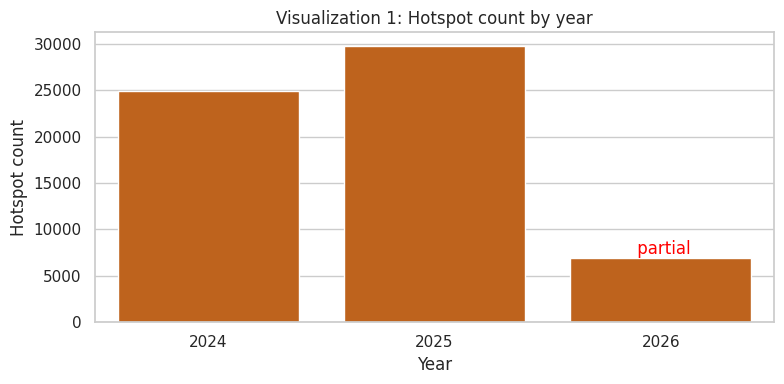

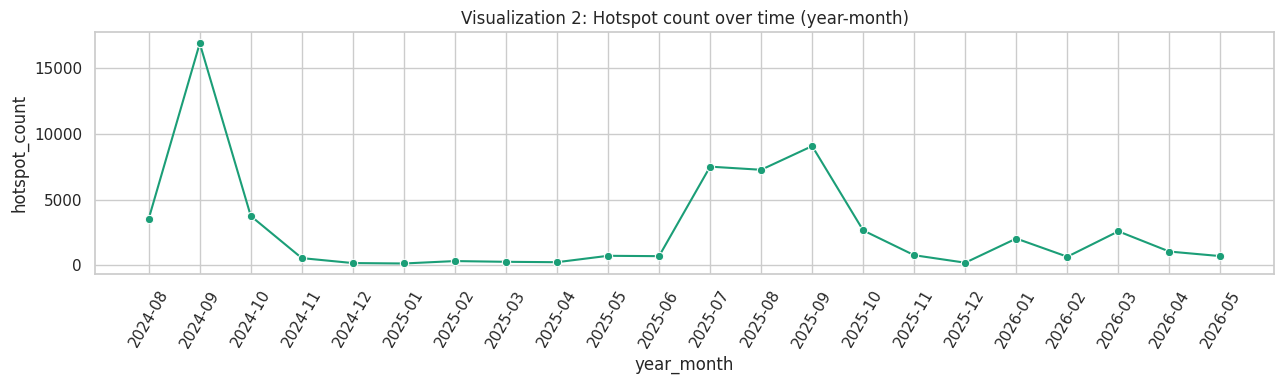

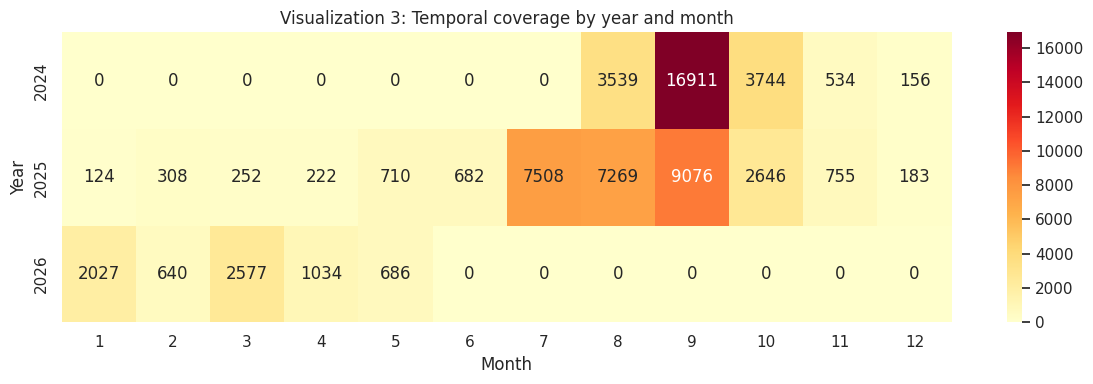

Partial years are explicitly flagged. Total hotspot counts from a partial year must not be directly compared with complete years without restricting all years to the same elapsed observation period.

In [9]:
if date_col:
    df['_datetime'] = pd.to_datetime(df[date_col], errors='coerce')
    df['year'] = df['_datetime'].dt.year
    df['month'] = df['_datetime'].dt.month
    df['month_name'] = df['_datetime'].dt.month_name()
    df['year_month'] = df['_datetime'].dt.to_period('M').astype(str)
    df['date'] = df['_datetime'].dt.date

    year_counts = df.groupby('year').size().rename('hotspot_count').reset_index()
    month_counts = df.groupby('month').size().rename('hotspot_count').reset_index()
    year_month_counts = df.groupby('year_month').size().rename('hotspot_count').reset_index()
    date_counts = df.groupby('date').size().rename('hotspot_count').reset_index()
    coverage = df.groupby(['year','month']).size().rename('hotspot_count').reset_index()
    calendar = pd.MultiIndex.from_product([sorted(df['year'].dropna().unique()), range(1,13)], names=['year','month']).to_frame(index=False)
    calendar = calendar.merge(coverage, on=['year','month'], how='left').fillna({'hotspot_count':0})
    missing_months = calendar[calendar['hotspot_count'].eq(0)]
    daily = df.groupby('date').size().rename('hotspot_count')
    full_dates = pd.date_range(df['_datetime'].min().normalize(), df['_datetime'].max().normalize(), freq='D').date
    temporal_gaps = pd.DataFrame({'date': list(pd.Index(full_dates).difference(pd.Index(daily.index)))})
    year_end = df.groupby('year')['_datetime'].max()
    incomplete_years = year_end[year_end.dt.month < 12].index.tolist()
    display(pd.DataFrame({'metric':['first_observation','last_observation','observed_days','missing_months','incomplete_years'], 'value':[df['_datetime'].min(),df['_datetime'].max(),df['date'].nunique(),len(missing_months),incomplete_years]}))
    display(year_counts); display(month_counts); display(year_month_counts); display(date_counts.head(20))
    display(Markdown(f'**Coverage diagnostics:** {len(missing_months)} year-month combinations have no records, and {len(temporal_gaps):,} dates have no detections within the observed span. Years ending before December are flagged as incomplete: **{incomplete_years}**.'))
    year_counts.to_csv(TAB/'hotspot_count_by_year.csv', index=False); month_counts.to_csv(TAB/'hotspot_count_by_month.csv', index=False); year_month_counts.to_csv(TAB/'hotspot_count_by_year_month.csv', index=False); date_counts.to_csv(TAB/'hotspot_count_by_date.csv', index=False); missing_months.to_csv(TAB/'missing_year_months.csv', index=False); temporal_gaps.to_csv(TAB/'temporal_gaps.csv', index=False)

    fig, ax = plt.subplots(figsize=(8,4)); sns.barplot(data=year_counts, x='year', y='hotspot_count', ax=ax, color='#d95f02'); ax.set_title('Visualization 1: Hotspot count by year'); ax.set_xlabel('Year'); ax.set_ylabel('Hotspot count');
    for year in incomplete_years: ax.text(list(year_counts['year']).index(year), year_counts.loc[year_counts['year'].eq(year),'hotspot_count'].iloc[0], ' partial', ha='center', va='bottom', color='red');
    plt.tight_layout(); fig.savefig(FIG/'hotspot_count_by_year.png', dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(13,4)); sns.lineplot(data=year_month_counts, x='year_month', y='hotspot_count', marker='o', ax=ax, color='#1b9e77'); ax.set_title('Visualization 2: Hotspot count over time (year-month)'); ax.tick_params(axis='x', rotation=60); plt.tight_layout(); fig.savefig(FIG/'hotspot_count_over_time.png', dpi=150); plt.show()

    heatmap_data = calendar.pivot(index='year', columns='month', values='hotspot_count'); fig, ax = plt.subplots(figsize=(12,4)); sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax); ax.set_title('Visualization 3: Temporal coverage by year and month'); ax.set_xlabel('Month'); ax.set_ylabel('Year'); plt.tight_layout(); fig.savefig(FIG/'temporal_coverage_heatmap.png', dpi=150); plt.show()
    display(Markdown('Partial years are explicitly flagged. Total hotspot counts from a partial year must not be directly compared with complete years without restricting all years to the same elapsed observation period.'))

In [10]:
df['_year'] = df['year']; df['_month'] = df['month']; df['_ym'] = df['year_month']; df['_date'] = df['date']

# 7. Temporal Pattern Analysis

Sekarang masuk ke pola waktu yang lebih dalam: musiman bulanan, perubahan year-over-year, sama pola deteksi siang vs malam. Frekuensi (jumlah deteksi) dan intensitas (FRP) sengaja dianalisis terpisah — jangan dicampur. Dan karena coverage 2026 masih parsial, itu selalu jadi pertimbangan tiap kali bandingin antar tahun.

## 7.1 Monthly Seasonality

Ngitung total & rata-rata deteksi per bulan kalender (Jan–Des, ditumpuk lintas tahun), terus juga diliat breakdown-nya per tahun secara terpisah biar ketauan apakah pola musimannya konsisten tiap tahun atau enggak.

,month,month_name,total_hotspots,average_hotspots_per_available_year
0,1,January,2151,717.000
1,2,February,948,316.000
2,3,March,2829,943.000
3,4,April,1256,418.667
4,5,May,1396,465.333
5,6,June,682,227.333
6,7,July,7508,"2,502.667"
7,8,August,10808,"3,602.667"
8,9,September,25987,"8,662.333"
9,10,October,6390,"2,130.000"


,year,month,hotspot_count
0,2024,8,3539
1,2024,9,16911
2,2024,10,3744
3,2024,11,534
4,2024,12,156
5,2025,1,124
6,2025,2,308
7,2025,3,252
8,2025,4,222
9,2025,5,710


**Seasonality interpretation:** Highest total activity occurs in **September** (25,987 detections); lowest occurs in **December** (339). Consistency should be judged from the year-separated table rather than assumed from the aggregate alone.

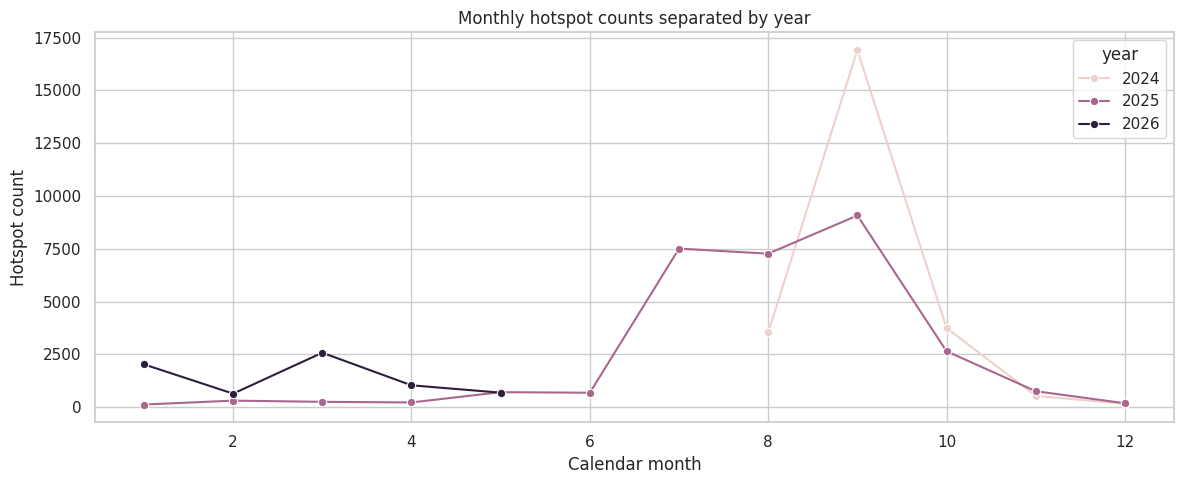

In [11]:
if date_col:
    month_summary = df.groupby(['month','month_name']).size().rename('total_hotspots').reset_index().sort_values('month')
    month_summary['average_hotspots_per_available_year'] = df.groupby('month').size().div(df['year'].nunique()).reindex(month_summary['month']).values
    yearly_month = df.groupby(['year','month']).size().rename('hotspot_count').reset_index()
    month_summary['month_name'] = pd.Categorical(month_summary['month_name'], categories=pd.date_range('2000-01-01', periods=12, freq='MS').month_name(), ordered=True)
    display(month_summary); display(yearly_month)
    peak_month = month_summary.loc[month_summary['total_hotspots'].idxmax()]; low_month = month_summary.loc[month_summary['total_hotspots'].idxmin()]
    display(Markdown(f'**Seasonality interpretation:** Highest total activity occurs in **{peak_month.month_name}** ({int(peak_month.total_hotspots):,} detections); lowest occurs in **{low_month.month_name}** ({int(low_month.total_hotspots):,}). Consistency should be judged from the year-separated table rather than assumed from the aggregate alone.'))
    month_summary.to_csv(TAB/'monthly_seasonality_summary.csv', index=False); yearly_month.to_csv(TAB/'monthly_counts_by_year.csv', index=False)
    fig, ax = plt.subplots(figsize=(12,5)); sns.lineplot(data=yearly_month, x='month', y='hotspot_count', hue='year', marker='o', ax=ax); ax.set(title='Monthly hotspot counts separated by year', xlabel='Calendar month', ylabel='Hotspot count'); plt.tight_layout(); fig.savefig(FIG/'monthly_seasonality_by_year.png', dpi=150); plt.show()

## 7.2 Year-over-Year Comparison

Bandingin frekuensi deteksi & intensitas FRP antar tahun — tapi dua-duanya dilihat terpisah, gak digabung jadi satu angka. Tahun yang datanya parsial (belum penuh) ditandain jelas, dan **gak boleh** dibandingin langsung head-to-head sama tahun yang udah lengkap kecuali pakai periode yang durasinya sama (elapsed period matching).

In [12]:
frp_column = quality.get('frp')
year_comparison = df.groupby('year').size().rename('total_hotspots').to_frame()
year_comparison['monthly_average_hotspots'] = df.groupby('year').size().div(df.groupby('year')['month'].nunique()).values
if frp_column:
    year_comparison['median_frp'] = df.groupby('year')[frp_column].median()
    year_comparison['mean_frp'] = df.groupby('year')[frp_column].mean()
if conf_column := quality.get('confidence'):
    confidence_by_year = pd.crosstab(df['year'], df[conf_column], normalize='index').mul(100).round(2)
    print('Confidence distribution by year (%):'); display(confidence_by_year); confidence_by_year.to_csv(TAB/'confidence_distribution_by_year.csv')
year_comparison['coverage_status'] = ['partial' if year in incomplete_years else 'complete/observed through December' for year in year_comparison.index]
display(year_comparison); year_comparison.to_csv(TAB/'year_over_year_comparison.csv')
display(Markdown('**Year-over-year interpretation:** Total and monthly-average hotspot counts describe detection frequency. Median and mean FRP describe detected radiant-power intensity. A higher hotspot count does not automatically imply higher fire severity, and partial-year totals require matched-period comparisons.'))

Confidence distribution by year (%):


confidence,h,l,n
year,,,
2024,3.380,3.580,93.040
2025,4.660,2.720,92.620
2026,1.340,3.560,95.100


,total_hotspots,monthly_average_hotspots,median_frp,mean_frp,coverage_status
year,,,,,
2024,24884,"4,976.800",6.410,10.895,complete/observed through December
2025,29735,"2,477.917",6.410,11.208,complete/observed through December
2026,6964,"1,392.800",4.375,6.684,partial


**Year-over-year interpretation:** Total and monthly-average hotspot counts describe detection frequency. Median and mean FRP describe detected radiant-power intensity. A higher hotspot count does not automatically imply higher fire severity, and partial-year totals require matched-period comparisons.

## 7.3 Day vs Night Analysis

Bandingin jumlah deteksi, FRP, confidence, sama brightness antara kategori `daynight` yang ada di data. Perbedaan yang muncul di sini bisa aja bukan murni karena beda jumlah kebakaran beneran, tapi karena karakteristik observasi/sensor yang emang beda antara siang & malam — jadi interpretasinya harus hati-hati, gak langsung disimpulin "malam lebih sedikit kebakaran".

In [13]:
daynight_column = 'daynight' if 'daynight' in df.columns else None
brightness_column = next((column for column in ['brightness','bright_ti4'] if column in df.columns), None)
if daynight_column:
    daynight_counts = df[daynight_column].value_counts(dropna=False).rename('detections').to_frame()
    daynight_counts['percentage'] = (daynight_counts['detections'] / len(df) * 100).round(2)
    display(daynight_counts)
    daynight_summary = df.groupby(daynight_column, dropna=False).agg(detections=(daynight_column,'size'))
    if frp_column: daynight_summary['median_frp'] = df.groupby(daynight_column, dropna=False)[frp_column].median(); daynight_summary['mean_frp'] = df.groupby(daynight_column, dropna=False)[frp_column].mean()
    if brightness_column: daynight_summary['median_brightness'] = df.groupby(daynight_column, dropna=False)[brightness_column].median(); daynight_summary['mean_brightness'] = df.groupby(daynight_column, dropna=False)[brightness_column].mean()
    display(daynight_summary); daynight_counts.to_csv(TAB/'daynight_counts.csv'); daynight_summary.to_csv(TAB/'daynight_summary.csv')
    if conf_column := quality.get('confidence'):
        daynight_confidence = pd.crosstab(df[daynight_column], df[conf_column], normalize='index').mul(100).round(2); display(daynight_confidence); daynight_confidence.to_csv(TAB/'confidence_distribution_daynight.csv')
    display(Markdown('**Day/night interpretation:** The count and percentage distributions describe detections, not necessarily fires. Fewer night detections cannot by themselves establish fewer nighttime fires because satellite overpass timing, illumination, cloud, detection thresholds, and other observation characteristics may influence the records.'))

,detections,percentage
daynight,,
D,54988,89.290
N,6595,10.710


,detections,median_frp,mean_frp,median_brightness,mean_brightness
daynight,,,,,
D,54988,6.830,11.611,337.190,338.982
N,6595,1.270,1.887,306.600,309.917


confidence,h,l,n
daynight,,,
D,4.180,3.540,92.280
N,0.350,0.000,99.650


**Day/night interpretation:** The count and percentage distributions describe detections, not necessarily fires. Fewer night detections cannot by themselves establish fewer nighttime fires because satellite overpass timing, illumination, cloud, detection thresholds, and other observation characteristics may influence the records.

# 8. Spatial Pattern Analysis

Di bagian ini cuma pakai latitude & longitude buat gambarin cakupan koordinat, sebaran geografis umum, sama kepadatannya. Belum ada data geospasial eksternal, boundary provinsi, spatial join, atau label provinsi apapun yang dipakai — itu baru masuk di 8.4.

## 8.1 Coordinate Distribution

Liat distribusi latitude & longitude satu-satu (histogram) terus juga gabungan, buat identifikasi cakupan geografis, pola koordinat yang mencurigakan, dan clustering kasar.

,count,mean,std,min,25%,50%,75%,max
latitude,"61,583.000",-0.171,1.437,-4.173,-1.053,-0.017,0.696,4.351
longitude,"61,583.000",112.666,2.845,108.684,110.415,111.569,115.238,119.499


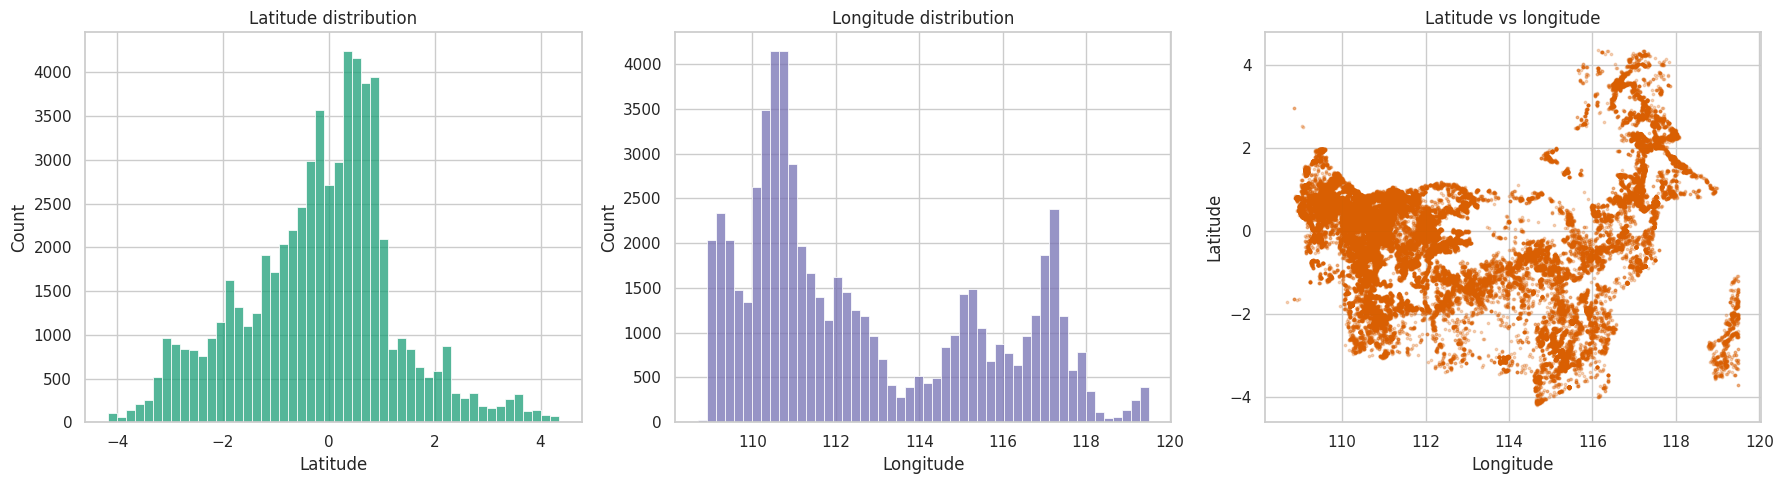

**Coordinate interpretation:** The histograms show the observed coordinate footprint, while the scatter plot highlights broad clustering and any isolated points. Suspicious records should be cross-checked against the coordinate-validation table; no province assignment is made.

In [14]:
lat = quality.get('latitude'); lon = quality.get('longitude')
if lat and lon:
    spatial_data = df[[lat, lon]].apply(pd.to_numeric, errors='coerce').dropna()
    display(spatial_data.describe().T)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(spatial_data[lat], bins=50, ax=axes[0], color='#1b9e77'); axes[0].set_title('Latitude distribution'); axes[0].set_xlabel('Latitude')
    sns.histplot(spatial_data[lon], bins=50, ax=axes[1], color='#7570b3'); axes[1].set_title('Longitude distribution'); axes[1].set_xlabel('Longitude')
    axes[2].scatter(spatial_data[lon], spatial_data[lat], s=3, alpha=.25, color='#d95f02'); axes[2].set_title('Latitude vs longitude'); axes[2].set_xlabel('Longitude'); axes[2].set_ylabel('Latitude')
    plt.tight_layout(); fig.savefig(FIG/'coordinate_distributions.png', dpi=150); plt.show()
    display(Markdown('**Coordinate interpretation:** The histograms show the observed coordinate footprint, while the scatter plot highlights broad clustering and any isolated points. Suspicious records should be cross-checked against the coordinate-validation table; no province assignment is made.'))

## 8.2 Spatial Distribution

Plot semua deteksi valid dalam bentuk scatter — longitude di sumbu-x, latitude di sumbu-y. Pakai marker kecil & transparan biar area yang padat gak numpuk jadi blob hitam doang (mengurangi overplotting).

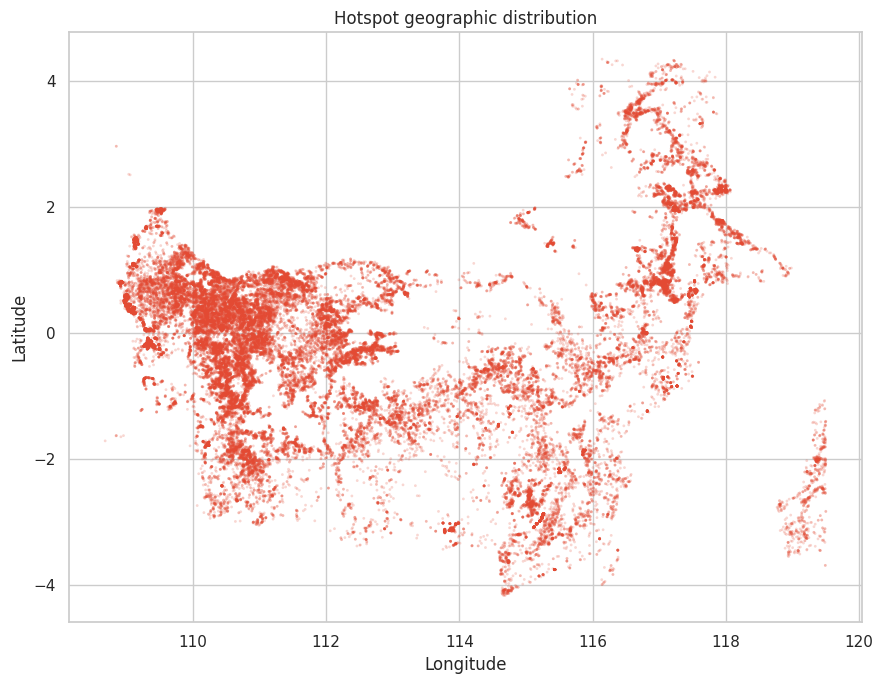

In [15]:
if lat and lon:
    fig, ax = plt.subplots(figsize=(9, 7)); ax.scatter(spatial_data[lon], spatial_data[lat], s=4, alpha=.22, color='#e34a33', edgecolors='none'); ax.set(xlabel='Longitude', ylabel='Latitude', title='Hotspot geographic distribution'); plt.tight_layout(); fig.savefig(FIG/'geographic_scatter.png', dpi=150); plt.show()

## 8.3 Spatial Density

Pakai hexbin plot buat nunjukin area yang densitasnya tinggi — hal-hal yang mungkin ketutupan/gak keliatan jelas kalau cuma pakai scatter plot biasa. Konsentrasi-konsentrasi ini masih dideskripsiin secara spasial murni aja (koordinat), belum di-assign ke provinsi mana pun.

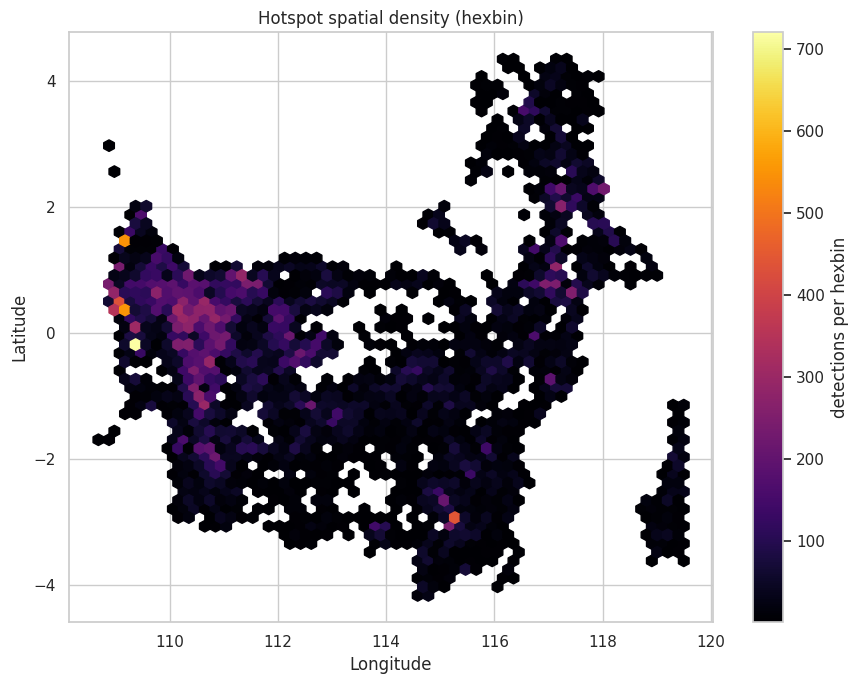

**Density interpretation:** The densest observed hexbin contains approximately **720 detections**. The highest-density cells identify major geographic concentrations in the observed records, while density can also reflect repeated detections and observation opportunity.

In [16]:
if lat and lon:
    fig, ax = plt.subplots(figsize=(9, 7)); density = ax.hexbin(spatial_data[lon], spatial_data[lat], gridsize=55, mincnt=1, cmap='inferno'); ax.set(xlabel='Longitude', ylabel='Latitude', title='Hotspot spatial density (hexbin)'); plt.colorbar(density, ax=ax, label='detections per hexbin'); plt.tight_layout(); fig.savefig(FIG/'spatial_hexbin.png', dpi=150); plt.show()
    top_hexbin_count = int(density.get_array().max())
    display(Markdown(f'**Density interpretation:** The densest observed hexbin contains approximately **{top_hexbin_count:,} detections**. The highest-density cells identify major geographic concentrations in the observed records, while density can also reflect repeated detections and observation opportunity.'))

## 8.4 Validasi Batas Wilayah Kalimantan (Geopandas)

Range koordinat yang udah dicek sebelumnya cuma mastiin lat/lon-nya masih dalam batas global yang valid — belum tentu titiknya beneran jatuh di daratan Kalimantan. Nah, sebagai pengecekan tambahan (pakai file batas provinsi eksternal, khusus buat validasi ini doang, **gak** digabung ke dataframe utama), tiap deteksi dicek secara point-in-polygon terhadap boundary Kalimantan, sekalian juga dicek terhadap boundary Sulawesi — soalnya pantai barat Sulawesi itu lumayan deket sama pantai timur Kalimantan kalau dilihat dari bounding box dataset ini, jadi perlu dipastiin gak ada titik yang "nyasar" ke sana.

,count,percentage
boundary_status,,
inside Kalimantan,60624,98.440
inside Sulawesi (likely mislabeled/adjacent),765,1.240
outside both boundaries,194,0.320


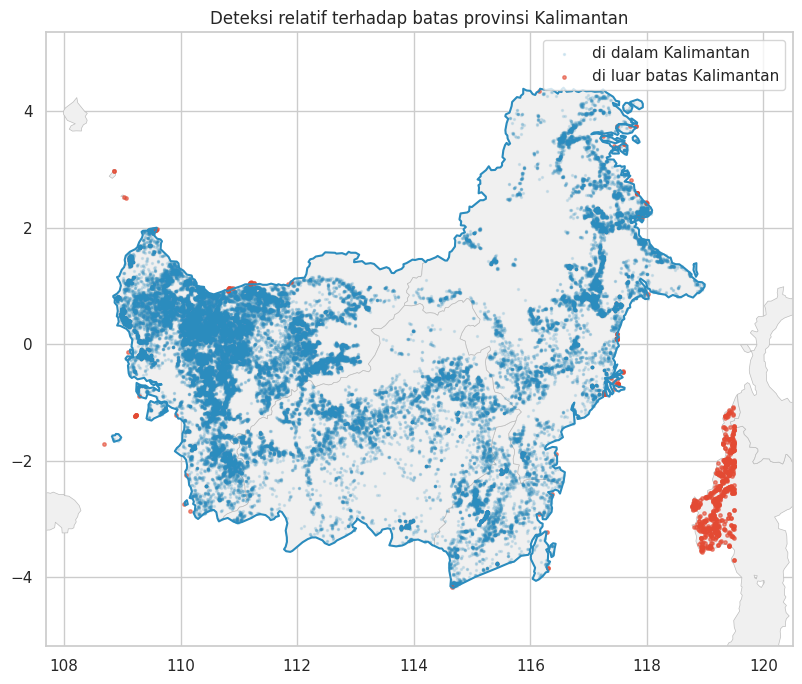

**Interpretasi batas wilayah:** **98.44%** deteksi benar-benar berada di dalam poligon Kalimantan dari data batas eksternal ini. Dari **959** titik yang berada di luar poligon Kalimantan, **765** di antaranya justru masuk poligon Sulawesi (pantai baratnya memang berdekatan dengan pantai timur Kalimantan pada rentang koordinat dataset ini), dan **194** sisanya tidak masuk poligon manapun. Dari sisa ini, **172** titik (89%) berjarak 5 km atau kurang dari garis pantai Kalimantan -- kemungkinan besar karena garis pantai pada file batas ini disederhanakan (simplified), bukan karena datanya salah. Hanya **10** titik yang jaraknya lebih dari 50 km, dan titik-titik ini pun masih berada di area yang masuk akal secara geografis (dekat pulau kecil atau perbatasan provinsi lain di sekitar Kalimantan), bukan koordinat acak seperti (0,0) atau di tengah laut lepas. Detail per titik ada di `kalimantan_boundary_outside_points.csv` kalau mau ditelusuri lebih lanjut. Perlu diingat, file batas yang dipakai di sini adalah data publik yang disederhanakan dan bukan sumber resmi (BIG/GADM), jadi cek ini sifatnya sanity check, bukan pengganti validasi batas administratif resmi.

In [17]:
import geopandas as gpd
import urllib.request
import ssl

boundary_url = 'https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-province-simple.json'
boundary_local_path = 'indonesia_province_boundaries.json'
boundary_check_available = True
try:
    unverified_context = ssl._create_unverified_context()
    with urllib.request.urlopen(boundary_url, context=unverified_context, timeout=30) as response, open(boundary_local_path, 'wb') as out_file:
        out_file.write(response.read())
    provinces = gpd.read_file(boundary_local_path)
except Exception as error:
    boundary_check_available = False
    print('Boundary file could not be loaded, skipping this check:', error)

if boundary_check_available and lat and lon:
    kalimantan_geom = provinces.loc[provinces['Propinsi'].str.contains('KALIMANTAN', case=False, na=False), 'geometry'].union_all()
    sulawesi_geom = provinces.loc[provinces['Propinsi'].str.contains('SULAWESI', case=False, na=False), 'geometry'].union_all()

    points = gpd.GeoDataFrame(spatial_data.copy(), geometry=gpd.points_from_xy(spatial_data[lon], spatial_data[lat]), crs='EPSG:4326')
    points['in_kalimantan'] = points.within(kalimantan_geom)
    points['in_sulawesi'] = points.within(sulawesi_geom)
    points['boundary_status'] = np.select(
        [points['in_kalimantan'], points['in_sulawesi']],
        ['inside Kalimantan', 'inside Sulawesi (likely mislabeled/adjacent)'],
        default='outside both boundaries'
    )
    boundary_summary = points['boundary_status'].value_counts().rename('count').to_frame()
    boundary_summary['percentage'] = (boundary_summary['count'] / len(points) * 100).round(2)
    display(boundary_summary)

    # For the points outside both polygons, measure how far they actually are from the Kalimantan
    # coastline (in a projected CRS) so "outside" can be read as "how far outside", not just yes/no.
    outside_points = points[~points['in_kalimantan'] & ~points['in_sulawesi']].copy()
    kalimantan_geom_proj = gpd.GeoSeries([kalimantan_geom], crs='EPSG:4326').to_crs(3395).iloc[0]
    outside_points_proj = outside_points.to_crs(3395)
    outside_points['distance_to_kalimantan_km'] = (outside_points_proj.geometry.distance(kalimantan_geom_proj) / 1000).round(2)
    near_coast = int((outside_points['distance_to_kalimantan_km'] <= 5).sum())
    far_outliers = outside_points[outside_points['distance_to_kalimantan_km'] > 50].sort_values('distance_to_kalimantan_km', ascending=False)
    boundary_summary.to_csv(TAB/'kalimantan_boundary_validation.csv')
    outside_points.drop(columns='geometry').to_csv(TAB/'kalimantan_boundary_outside_points.csv', index=False)

    fig, ax = plt.subplots(figsize=(9, 7))
    provinces.plot(ax=ax, color='#f0f0f0', edgecolor='#bdbdbd', linewidth=.5)
    gpd.GeoSeries([kalimantan_geom], crs='EPSG:4326').boundary.plot(ax=ax, color='#2b8cbe', linewidth=1.5)
    points[points['in_kalimantan']].plot(ax=ax, markersize=2, alpha=.15, color='#2b8cbe', label='di dalam Kalimantan')
    points[~points['in_kalimantan']].plot(ax=ax, markersize=6, alpha=.6, color='#e34a33', label='di luar batas Kalimantan')
    ax.set_xlim(spatial_data[lon].min() - 1, spatial_data[lon].max() + 1)
    ax.set_ylim(spatial_data[lat].min() - 1, spatial_data[lat].max() + 1)
    ax.set_title('Deteksi relatif terhadap batas provinsi Kalimantan')
    ax.legend()
    plt.tight_layout(); fig.savefig(FIG/'kalimantan_boundary_check.png', dpi=150); plt.show()

    n_outside = int((~points['in_kalimantan']).sum())
    n_sulawesi = int(points['in_sulawesi'].sum())
    n_outside_both = len(outside_points)
    pct_inside = round(points['in_kalimantan'].mean() * 100, 2)
    display(Markdown(f'''**Interpretasi batas wilayah:** **{pct_inside}%** deteksi benar-benar berada di dalam poligon Kalimantan dari data batas eksternal ini. Dari **{n_outside:,}** titik yang berada di luar poligon Kalimantan, **{n_sulawesi:,}** di antaranya justru masuk poligon Sulawesi (pantai baratnya memang berdekatan dengan pantai timur Kalimantan pada rentang koordinat dataset ini), dan **{n_outside_both:,}** sisanya tidak masuk poligon manapun. Dari sisa ini, **{near_coast}** titik ({near_coast/n_outside_both*100:.0f}%) berjarak 5 km atau kurang dari garis pantai Kalimantan -- kemungkinan besar karena garis pantai pada file batas ini disederhanakan (simplified), bukan karena datanya salah. Hanya **{len(far_outliers)}** titik yang jaraknya lebih dari 50 km, dan titik-titik ini pun masih berada di area yang masuk akal secara geografis (dekat pulau kecil atau perbatasan provinsi lain di sekitar Kalimantan), bukan koordinat acak seperti (0,0) atau di tengah laut lepas. Detail per titik ada di `kalimantan_boundary_outside_points.csv` kalau mau ditelusuri lebih lanjut. Perlu diingat, file batas yang dipakai di sini adalah data publik yang disederhanakan dan bukan sumber resmi (BIG/GADM), jadi cek ini sifatnya sanity check, bukan pengganti validasi batas administratif resmi.'''))


## 8.5 Lokasi Hotspot yang Berulang (Persistent)

Selain snapshot kepadatan sesaat (yang dari hexbin di atas), di sini deteksi-deteksi dikelompokin ke sel grid koordinat kecil (~5-6 km per sel), terus dihitung berapa bulan kalender berbeda tiap sel itu "aktif" (ada deteksi). Ini kegunaannya buat bedain: lokasi yang cuma kena satu kejadian kebakaran gede sekali doang, vs lokasi yang emang kebakaran berulang/kronis dari bulan ke bulan (contoh khas: lahan gambut yang udah terdegradasi, biasanya smoldering terus-terusan).

In [18]:
if lat and lon:
    grid_size = 0.05  # roughly 5-6 km per cell
    grid = spatial_data.copy()
    grid['lat_bin'] = (grid[lat] // grid_size) * grid_size
    grid['lon_bin'] = (grid[lon] // grid_size) * grid_size
    grid['year_month'] = df.loc[grid.index, 'year_month']
    persistent = (grid.groupby(['lat_bin', 'lon_bin'])
                       .agg(detections=('year_month', 'size'), distinct_year_months=('year_month', 'nunique'))
                       .reset_index()
                       .sort_values(['distinct_year_months', 'detections'], ascending=False))
    display(persistent.head(15))
    persistent.to_csv(TAB/'persistent_hotspot_cells.csv', index=False)
    top_cell = persistent.iloc[0]
    display(Markdown(f'''**Persistent-location interpretation:** Grouping detections into ~{grid_size}-degree grid cells shows the most recurring cell was active in **{int(top_cell.distinct_year_months)}** distinct year-month periods (**{int(top_cell.detections):,}** total detections at that cell), which points to a location with repeated/chronic burning rather than a single event. This is a descriptive spatial-frequency check, not a clustering model, and cell boundaries are arbitrary grid lines rather than natural fire-area edges.'''))


,lat_bin,lon_bin,detections,distinct_year_months
1664,-1.900,115.850,121,20
536,-2.900,115.250,233,19
3339,-0.750,117.050,159,17
3087,-0.900,117.150,30,17
6673,1.300,116.650,87,16
5533,0.500,117.200,44,16
2347,-1.350,113.050,62,15
2182,-1.500,114.550,53,15
6123,0.800,116.950,38,15
486,-2.950,115.200,131,14


**Persistent-location interpretation:** Grouping detections into ~0.05-degree grid cells shows the most recurring cell was active in **20** distinct year-month periods (**121** total detections at that cell), which points to a location with repeated/chronic burning rather than a single event. This is a descriptive spatial-frequency check, not a clustering model, and cell boundaries are arbitrary grid lines rather than natural fire-area edges.

# 9. Fire Intensity Analysis

Analisis `frp`, `brightness`, sama `bright_t31` sebagai variabel deteksi termal. FRP di sini diperlakukan sebagai *instantaneous radiant power* yang kedeteksi saat itu — **bukan** luas area terbakar dan **bukan** total energi kebakaran secara keseluruhan. Mean & median dilaporin terpisah karena variabel termal kayak gini biasanya skewed banget (gak simetris), jadi mean doang bisa menyesatkan.

,mean,median,standard_deviation,minimum,maximum,p75,p90,p95,p99,missing
frp,10.570,6.140,17.424,0.090,954.790,11.430,22.110,32.909,70.197,0.000
brightness,335.870,335.860,13.677,207.930,367.000,342.220,350.860,356.050,367.000,0.000
bright_t31,292.131,292.990,6.517,241.480,361.810,296.270,298.868,300.570,304.420,0.000


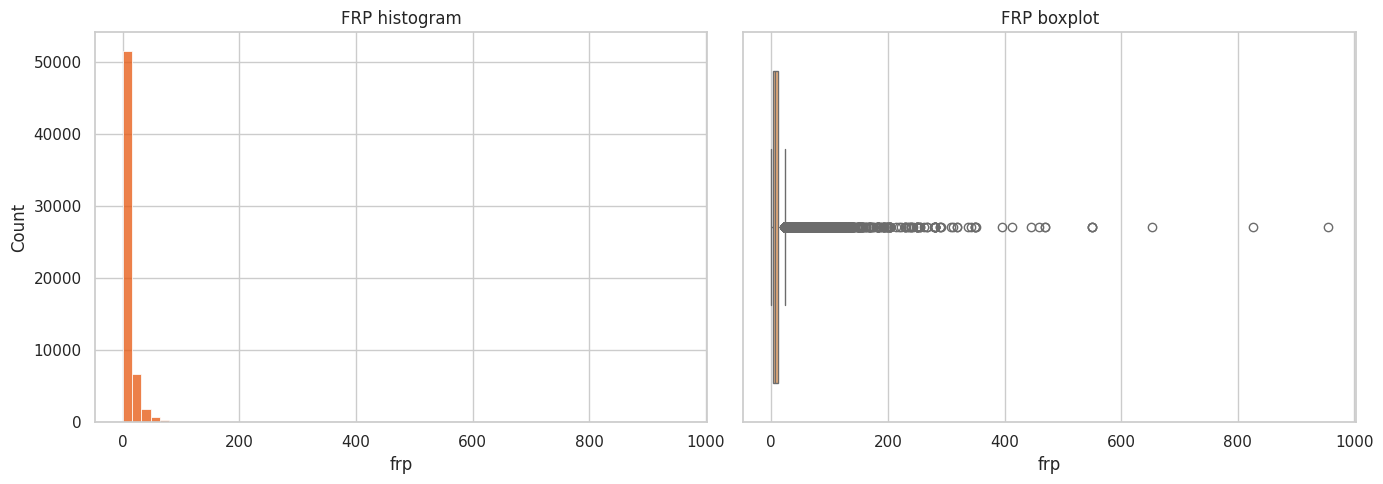

**FRP interpretation:** FRP skewness is **13.08**. Mean FRP (**10.57**) versus median FRP (**6.14**) and the upper percentiles should be compared; when the mean is pulled upward by a long tail, the median and percentiles are more representative of a typical detection.

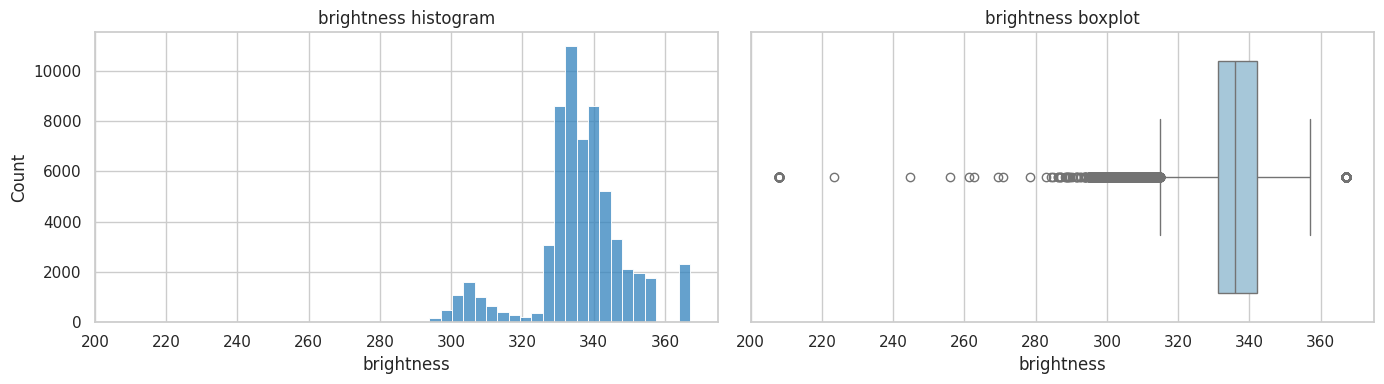

**brightness interpretation:** The summary and plots show its central tendency, spread, skewness, and extreme values. Compare these distributions with each other rather than treating either brightness variable as a direct measure of total fire severity.

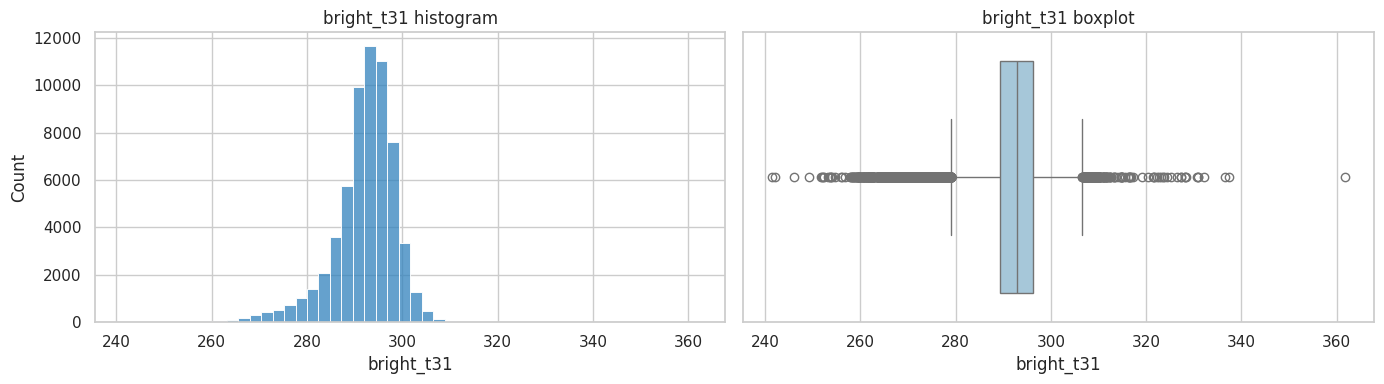

**bright_t31 interpretation:** The summary and plots show its central tendency, spread, skewness, and extreme values. Compare these distributions with each other rather than treating either brightness variable as a direct measure of total fire severity.

,month,month_name,count,mean,median
0,1,January,2151,5.793,3.870
1,2,February,948,6.417,4.395
2,3,March,2829,10.528,4.950
3,4,April,1256,5.923,3.985
4,5,May,1396,6.189,3.990
5,6,June,682,5.965,3.830
6,7,July,7508,11.621,6.030
7,8,August,10808,11.528,7.080
8,9,September,25987,11.566,6.910
9,10,October,6390,9.514,5.510


,year,count,mean,median
0,2024,24884,10.895,6.410
1,2025,29735,11.208,6.410
2,2026,6964,6.684,4.375


,daynight,count,mean,median
0,D,54988,11.611,6.830
1,N,6595,1.887,1.270


,month,month_name,hotspot_count,mean,median
0,1,January,2151,5.793,3.870
1,2,February,948,6.417,4.395
2,3,March,2829,10.528,4.950
3,4,April,1256,5.923,3.985
4,5,May,1396,6.189,3.990
5,6,June,682,5.965,3.830
6,7,July,7508,11.621,6.030
7,8,August,10808,11.528,7.080
8,9,September,25987,11.566,6.910
9,10,October,6390,9.514,5.510


**Intensity-over-time interpretation:** Compare hotspot counts with both mean and median FRP. Months with more detections do not necessarily have higher detected intensity; a matching or differing pattern must be established from the grouped results above.

In [19]:
frp = quality.get('frp')
brightness_column = next((column for column in ['brightness','bright_ti4'] if column in df.columns), None)
bright_t31_column = 'bright_t31' if 'bright_t31' in df.columns else None

def intensity_summary(column):
    values = pd.to_numeric(df[column], errors='coerce').dropna()
    return pd.Series({'mean':values.mean(),'median':values.median(),'standard_deviation':values.std(),'minimum':values.min(),'maximum':values.max(),'p75':values.quantile(.75),'p90':values.quantile(.90),'p95':values.quantile(.95),'p99':values.quantile(.99),'missing':df[column].isna().sum()}, name=column)

intensity_columns = [column for column in [frp, brightness_column, bright_t31_column] if column]
if intensity_columns:
    all_intensity_summary = pd.concat([intensity_summary(column) for column in intensity_columns], axis=1).T
    display(all_intensity_summary); all_intensity_summary.to_csv(TAB/'thermal_variable_summary.csv')

if frp:
    frp_values = pd.to_numeric(df[frp], errors='coerce').dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)); sns.histplot(frp_values, bins=60, ax=axes[0], color='#e6550d'); axes[0].set_title('FRP histogram'); sns.boxplot(x=frp_values, ax=axes[1], color='#fdae6b'); axes[1].set_title('FRP boxplot'); plt.tight_layout(); fig.savefig(FIG/'frp_distribution.png', dpi=150); plt.show()
    skewness = frp_values.skew(); display(Markdown(f'**FRP interpretation:** FRP skewness is **{skewness:.2f}**. Mean FRP (**{frp_values.mean():.2f}**) versus median FRP (**{frp_values.median():.2f}**) and the upper percentiles should be compared; when the mean is pulled upward by a long tail, the median and percentiles are more representative of a typical detection.'))

for label, column in [('brightness', brightness_column), ('bright_t31', bright_t31_column)]:
    if column:
        values = pd.to_numeric(df[column], errors='coerce').dropna()
        fig, axes = plt.subplots(1, 2, figsize=(14, 4)); sns.histplot(values, bins=50, ax=axes[0], color='#3182bd'); axes[0].set_title(f'{label} histogram'); sns.boxplot(x=values, ax=axes[1], color='#9ecae1'); axes[1].set_title(f'{label} boxplot'); plt.tight_layout(); fig.savefig(FIG/f'{label}_distribution.png', dpi=150); plt.show()
        display(Markdown(f'**{label} interpretation:** The summary and plots show its central tendency, spread, skewness, and extreme values. Compare these distributions with each other rather than treating either brightness variable as a direct measure of total fire severity.'))

if frp and date_col:
    frp_by_month = df.groupby(['month','month_name'])[frp].agg(['count','mean','median']).reset_index().sort_values('month')
    frp_by_year = df.groupby('year')[frp].agg(['count','mean','median']).reset_index()
    display(frp_by_month); display(frp_by_year)
    frp_by_month.to_csv(TAB/'frp_by_month.csv', index=False); frp_by_year.to_csv(TAB/'frp_by_year.csv', index=False)
    if 'daynight' in df.columns:
        frp_by_daynight = df.groupby('daynight', dropna=False)[frp].agg(['count','mean','median']).reset_index(); display(frp_by_daynight); frp_by_daynight.to_csv(TAB/'frp_by_daynight.csv', index=False)
    frequency_month = df.groupby('month').size().rename('hotspot_count')
    intensity_frequency = frp_by_month.set_index('month').join(frequency_month).reset_index()
    display(intensity_frequency[['month','month_name','hotspot_count','mean','median']])
    display(Markdown('**Intensity-over-time interpretation:** Compare hotspot counts with both mean and median FRP. Months with more detections do not necessarily have higher detected intensity; a matching or differing pattern must be established from the grouped results above.'))

# 10. Confidence Analysis

Ngecek distribusi kolom `confidence` sama hubungannya sama FRP dan waktu. Penting: `confidence` di sini dievaluasi sebagai indikator **kualitas deteksi** (seberapa yakin sensor dengan hasil deteksinya), bukan sebagai indikator **severity/keparahan kebakaran**. Dua hal ini gampang ketuker kalau gak hati-hati.

,detections
confidence,
n,57315
h,2320
l,1948


,frp
frp,1.000


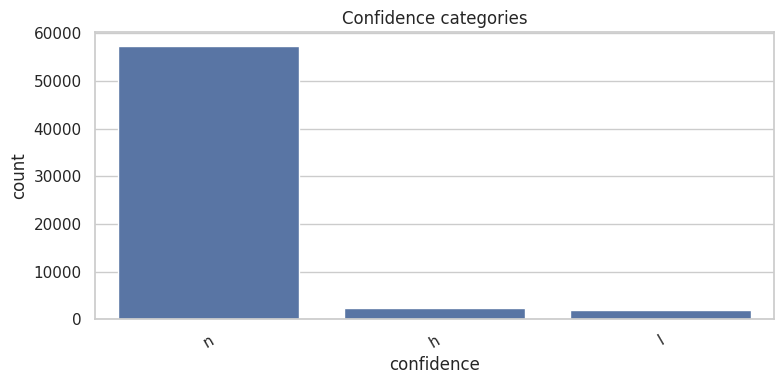

**Confidence interpretation:** The distribution above shows whether confidence is imbalanced or missing. Any association with FRP should be interpreted cautiously because detection conditions and instrument thresholds can affect both variables.

In [20]:
conf=quality.get('confidence')
if conf:
    display(df[conf].value_counts(dropna=False).rename_axis('confidence').to_frame('detections'))
    if frp: display(df[[conf,frp]].corr(numeric_only=True))
    fig,ax=plt.subplots(figsize=(8,4)); sns.countplot(data=df,x=conf,order=df[conf].value_counts().index,ax=ax); ax.set_title('Confidence categories'); plt.xticks(rotation=30); plt.tight_layout(); fig.savefig(FIG/'confidence_distribution.png',dpi=150); plt.show()
    display(Markdown('**Confidence interpretation:** The distribution above shows whether confidence is imbalanced or missing. Any association with FRP should be interpreted cautiously because detection conditions and instrument thresholds can affect both variables.'))

## 10.1 Confidence Distribution

Rangkum jumlah & persentase tiap kategori confidence — secara keseluruhan, terus dipecah lagi per tahun, per bulan, dan per siang/malam.

,count,percentage
confidence,,
n,57315,93.070
h,2320,3.770
l,1948,3.160


confidence,h,l,n
year,,,
2024,3.380,3.580,93.040
2025,4.660,2.720,92.620
2026,1.340,3.560,95.100


confidence,h,l,n
month,,,
1,0.420,1.530,98.050
2,0.630,3.800,95.570
3,2.230,7.280,90.490
4,1.670,1.430,96.890
5,0.640,1.070,98.280
6,0.290,0.290,99.410
7,3.160,2.740,94.100
8,4.890,1.990,93.120
9,4.990,3.730,91.280


confidence,h,l,n
daynight,,,
D,4.180,3.540,92.280
N,0.350,0.000,99.650


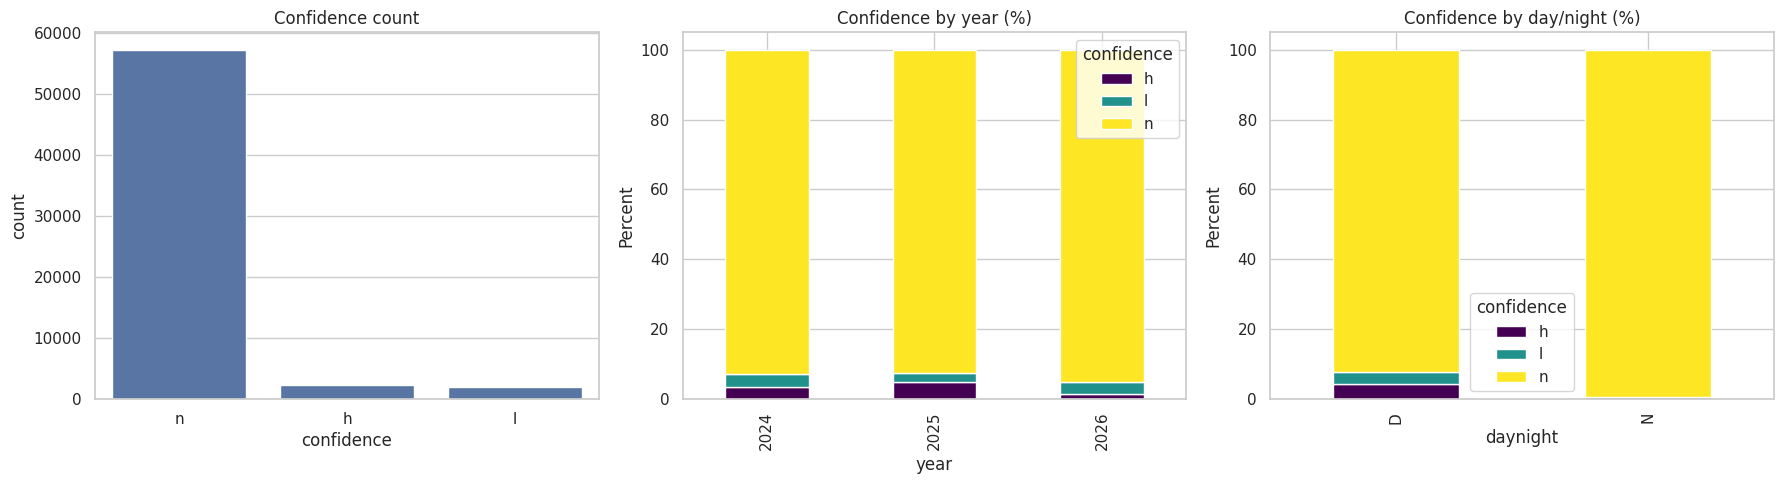

In [21]:
conf = quality.get('confidence')
if conf:
    confidence_counts = df[conf].value_counts(dropna=False).rename('count').to_frame(); confidence_counts['percentage'] = confidence_counts['count'].div(len(df)).mul(100).round(2); display(confidence_counts)
    confidence_by_year = pd.crosstab(df['year'], df[conf], normalize='index').mul(100).round(2); confidence_by_month = pd.crosstab(df['month'], df[conf], normalize='index').mul(100).round(2)
    display(confidence_by_year); display(confidence_by_month)
    if 'daynight' in df.columns: confidence_by_daynight = pd.crosstab(df['daynight'], df[conf], normalize='index').mul(100).round(2); display(confidence_by_daynight)
    confidence_counts.to_csv(TAB/'confidence_counts_percentages.csv'); confidence_by_year.to_csv(TAB/'confidence_by_year.csv'); confidence_by_month.to_csv(TAB/'confidence_by_month.csv')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5)); sns.countplot(data=df, x=conf, order=df[conf].value_counts().index, ax=axes[0]); axes[0].set_title('Confidence count')
    confidence_by_year.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis'); axes[1].set_title('Confidence by year (%)'); axes[1].set_ylabel('Percent')
    if 'daynight' in df.columns: confidence_by_daynight.plot(kind='bar', stacked=True, ax=axes[2], colormap='viridis'); axes[2].set_title('Confidence by day/night (%)'); axes[2].set_ylabel('Percent')
    plt.tight_layout(); fig.savefig(FIG/'confidence_distributions.png', dpi=150); plt.show()

## 10.2 FRP vs Confidence

Bandingin distribusi FRP & statistik ringkasan yang robust (median, percentile) di tiap kategori confidence, termasuk liat overlap antar kategori lewat boxplot.

,count,mean,median,p75,p90,p95
confidence,,,,,,
h,2320,18.371,13.360,20.275,32.596,45.391
l,1948,28.857,12.765,27.703,62.488,103.473
n,57315,9.633,5.820,10.540,20.440,30.490


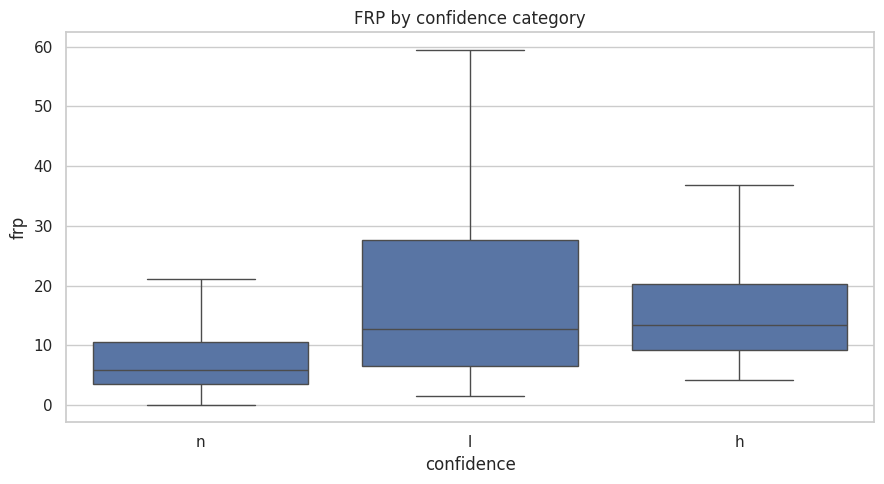

**FRP-confidence interpretation:** Use the category medians, percentiles, and boxplot overlap to assess whether confidence tracks detected FRP. A monotonic increase would support an association, but substantial overlap would limit confidence as a standalone intensity proxy.

In [22]:
if conf and frp:
    frp_confidence = df.groupby(conf, dropna=False)[frp].agg(['count','mean','median',lambda x:x.quantile(.75),lambda x:x.quantile(.90),lambda x:x.quantile(.95)]).rename(columns={'<lambda_0>':'p75','<lambda_1>':'p90','<lambda_2>':'p95'}); display(frp_confidence)
    fig, ax = plt.subplots(figsize=(9, 5)); sns.boxplot(data=df, x=conf, y=frp, ax=ax, showfliers=False); ax.set_title('FRP by confidence category'); plt.tight_layout(); fig.savefig(FIG/'frp_by_confidence.png', dpi=150); plt.show()
    frp_confidence.to_csv(TAB/'frp_by_confidence.csv')
    display(Markdown('**FRP-confidence interpretation:** Use the category medians, percentiles, and boxplot overlap to assess whether confidence tracks detected FRP. A monotonic increase would support an association, but substantial overlap would limit confidence as a standalone intensity proxy.'))

## 10.3 Brightness vs Confidence

Bandingin distribusi brightness & Bright_T31 di tiap kategori confidence, buat ngecek apakah confidence itu ada kaitannya sama kekuatan sinyal termal atau enggak.

,count,mean,median,min,max
confidence,,,,,
h,2320,367.000,367.000,367.000,367.000
l,1948,335.408,334.580,207.930,367.000
n,57315,334.625,335.450,295.040,356.760


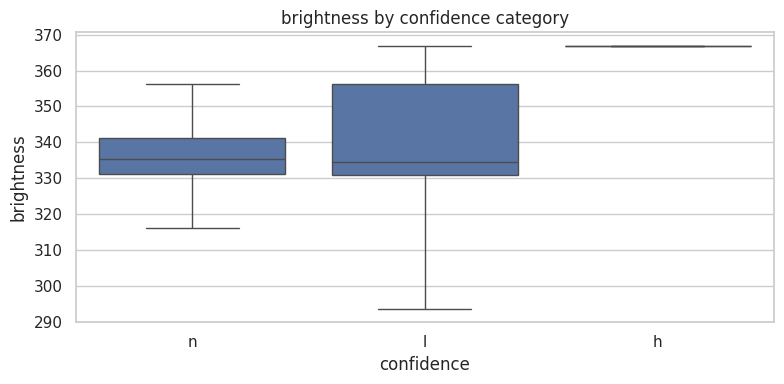

,count,mean,median,min,max
confidence,,,,,
h,2320,293.433,292.890,274.320,332.160
l,1948,295.034,295.985,261.910,361.810
n,57315,291.980,292.940,241.480,316.580


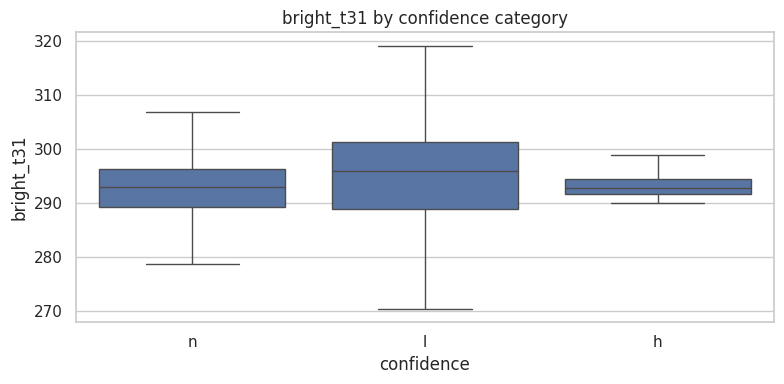

**Thermal-signal interpretation:** Differences in brightness or Bright_T31 across confidence categories indicate possible association with thermal signal, but category overlap and observation conditions must be considered.

In [23]:
thermal_by_confidence = [column for column in [brightness_column, bright_t31_column] if column]
if conf and thermal_by_confidence:
    for column in thermal_by_confidence:
        display(df.groupby(conf, dropna=False)[column].agg(['count','mean','median','min','max']))
        plt.figure(figsize=(8, 4)); sns.boxplot(data=df, x=conf, y=column, showfliers=False); plt.title(f'{column} by confidence category'); plt.tight_layout(); plt.savefig(FIG/f'{column}_by_confidence.png', dpi=150); plt.show()
    display(Markdown('**Thermal-signal interpretation:** Differences in brightness or Bright_T31 across confidence categories indicate possible association with thermal signal, but category overlap and observation conditions must be considered.'))

## 10.4 Low Confidence Sensitivity Analysis

Bandingin hasil kalau pakai semua record, vs skenario alternatif di mana kategori confidence paling rendah (`low`) di-exclude. Ini cuma buat lihat *seberapa sensitif* hasil analisis ke keputusan itu — **bukan** buat modifikasi atau ganti dataset sumbernya.

In [24]:
if conf:
    ordered_confidence = list(df[conf].dropna().unique())
    low_confidence_category = ordered_confidence[0] if ordered_confidence else None
    scenario_a = df.copy()
    scenario_b = df[df[conf].ne(low_confidence_category)].copy() if low_confidence_category is not None else df.copy()
    def scenario_summary(data, label):
        result = data.groupby('month').size().rename('hotspot_count').to_frame(); result['scenario'] = label; result['median_frp'] = data.groupby('month')[frp].median() if frp else np.nan; result['year'] = data.groupby('month')['year'].first(); return result.reset_index()
    sensitivity = pd.concat([scenario_summary(scenario_a,'A: all records'), scenario_summary(scenario_b,'B: exclude lowest confidence')])
    display(sensitivity); sensitivity.to_csv(TAB/'low_confidence_sensitivity_by_month.csv', index=False)
    peak_a = scenario_a.groupby('month').size().idxmax(); peak_b = scenario_b.groupby('month').size().idxmax()
    yearly_sensitivity = pd.concat([scenario_a.groupby('year').size().rename('all_records'), scenario_b.groupby('year').size().rename('exclude_low_confidence')], axis=1); display(yearly_sensitivity); yearly_sensitivity.to_csv(TAB/'low_confidence_sensitivity_by_year.csv')
    display(Markdown(f'**Sensitivity interpretation:** Scenario A peak month is **{peak_a}** and Scenario B peak month is **{peak_b}** after excluding the lowest observed category (**{low_confidence_category}**). Compare the tables and median FRP values before deciding whether low-confidence records materially alter conclusions; they are not automatically removed.'))

,month,hotspot_count,scenario,median_frp,year
0,1,2151,A: all records,3.870,2025
1,2,948,A: all records,4.395,2025
2,3,2829,A: all records,4.950,2025
3,4,1256,A: all records,3.985,2025
4,5,1396,A: all records,3.990,2025
5,6,682,A: all records,3.830,2025
6,7,7508,A: all records,6.030,2025
7,8,10808,A: all records,7.080,2024
8,9,25987,A: all records,6.910,2024
9,10,6390,A: all records,5.510,2024


,all_records,exclude_low_confidence
year,,
2024,24884,1733
2025,29735,2194
2026,6964,341


**Sensitivity interpretation:** Scenario A peak month is **9** and Scenario B peak month is **9** after excluding the lowest observed category (**n**). Compare the tables and median FRP values before deciding whether low-confidence records materially alter conclusions; they are not automatically removed.

# 11. Sensor & Observation Analysis

Cek field-field yang berhubungan sama sensor/platform, sama variabel geometri observasi kayak `scan` dan `track` (kalau ada). Variabel-variabel ini bantu identifikasi efek dari sistem deteksinya sendiri — yang kalau gak diwaspadai, bisa salah diinterpretasi seolah-olah itu perbedaan kebakaran beneran.

In [25]:
cat_cols=[c for c in df.columns if df[c].dtype=='object' and c not in ['_date','_ym']]
for c in cat_cols[:8]:
    if df[c].nunique(dropna=False)<=30: display(df[c].value_counts(dropna=False).rename_axis(c).to_frame('detections'))
obs=[c for c in [quality.get('scan'),quality.get('track')] if c]
if obs: display(df[obs].describe().T)

,count,mean,std,min,25%,50%,75%,max
scan,"61,583.000",0.460,0.087,0.320,0.390,0.440,0.510,0.800
track,"61,583.000",0.484,0.109,0.360,0.390,0.460,0.560,0.780


## 11.1 Satellite and Instrument

Cek nilai unik dari kolom satellite & instrument, secara keseluruhan dan per tahun, buat mastiin metadata-nya konsisten (misal gak ketuker-tuker antar satelit/sensor).

In [26]:
metadata_columns = [column for column in ['satellite','instrument'] if column in df.columns]
for column in metadata_columns:
    print(f'{column}: {df[column].nunique(dropna=True)} unique values')
    display(df[column].value_counts(dropna=False).rename('count').to_frame())
    if 'year' in df.columns: display(pd.crosstab(df['year'], df[column]))
display(Markdown('**Satellite/instrument interpretation:** If only one value is present, the dataset cannot support comparisons across satellites or instruments. Year consistency is assessed from the displayed cross-tabs.'))

satellite: 1 unique values


,count
satellite,
N20,61583


satellite,N20
year,
2024,24884
2025,29735
2026,6964


instrument: 1 unique values


,count
instrument,
VIIRS,61583


instrument,VIIRS
year,
2024,24884
2025,29735
2026,6964


**Satellite/instrument interpretation:** If only one value is present, the dataset cannot support comparisons across satellites or instruments. Year consistency is assessed from the displayed cross-tabs.

## 11.2 Version

Cek versi dataset yang tercatat, dan apakah nilai version-nya berubah-ubah antar tahun/periode waktu.

In [27]:
if 'version' in df.columns:
    version_counts = df['version'].value_counts(dropna=False).rename('count').to_frame(); display(version_counts)
    if 'year' in df.columns: display(pd.crosstab(df['year'], df['version']))
    if 'year_month' in df.columns: display(pd.crosstab(df['year_month'], df['version']).tail(30))
    version_counts.to_csv(TAB/'version_summary.csv')
    display(Markdown('**Version interpretation:** Changes in version across years or months may introduce comparability or processing-consistency issues and should be documented before trend analysis.'))

,count
version,
2,61583


version,2
year,
2024,24884
2025,29735
2026,6964


version,2
year_month,
2024-08,3539
2024-09,16911
2024-10,3744
2024-11,534
2024-12,156
2025-01,124
2025-02,308
2025-03,252
2025-04,222


**Version interpretation:** Changes in version across years or months may introduce comparability or processing-consistency issues and should be documented before trend analysis.

## 11.3 Scan and Track

Rangkum nilai `scan` & `track`, liat distribusi & observasi ekstremnya, terus evaluasi variasi yang keliatan — tanpa langsung nganggep dua variabel ini bakal berguna buat scoring ke depannya (itu evaluasi terpisah di bagian 13).

,metric,value,variable
0,count,"61,583.000",scan
1,missing,0.000,scan
2,mean,0.460,scan
3,median,0.440,scan
4,std,0.087,scan
5,min,0.320,scan
6,p01,0.320,scan
7,p99,0.740,scan
8,max,0.800,scan


scan observations at or above the 99th percentile: 692


,scan
8134,0.800
8132,0.800
8138,0.800
45689,0.800
24341,0.800
45451,0.800
45453,0.800
45420,0.800
45449,0.800
45463,0.800


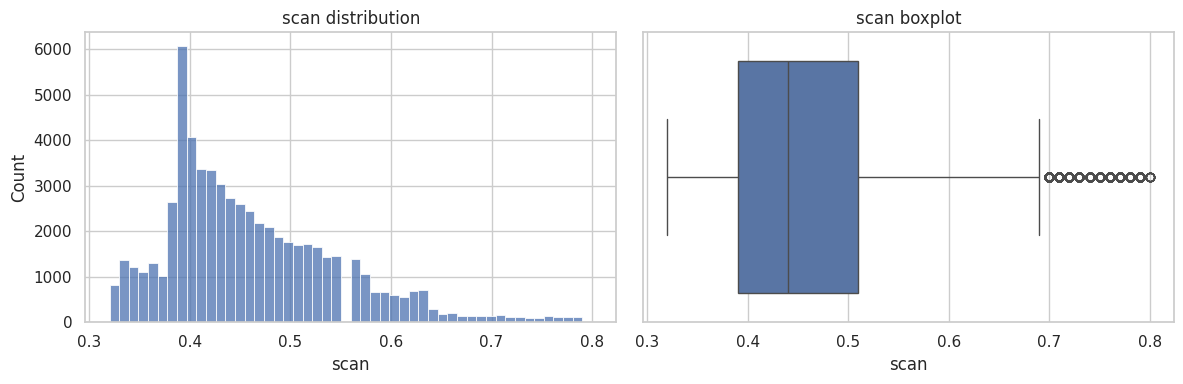

,metric,value,variable
0,count,"61,583.000",track
1,missing,0.000,track
2,mean,0.484,track
3,median,0.460,track
4,std,0.109,track
5,min,0.360,track
6,p01,0.360,track
7,p99,0.760,track
8,max,0.780,track


track observations at or above the 99th percentile: 870


,track
888,0.780
886,0.780
243,0.780
2609,0.780
61430,0.780
38367,0.780
38374,0.780
38375,0.780
38376,0.780
38377,0.780


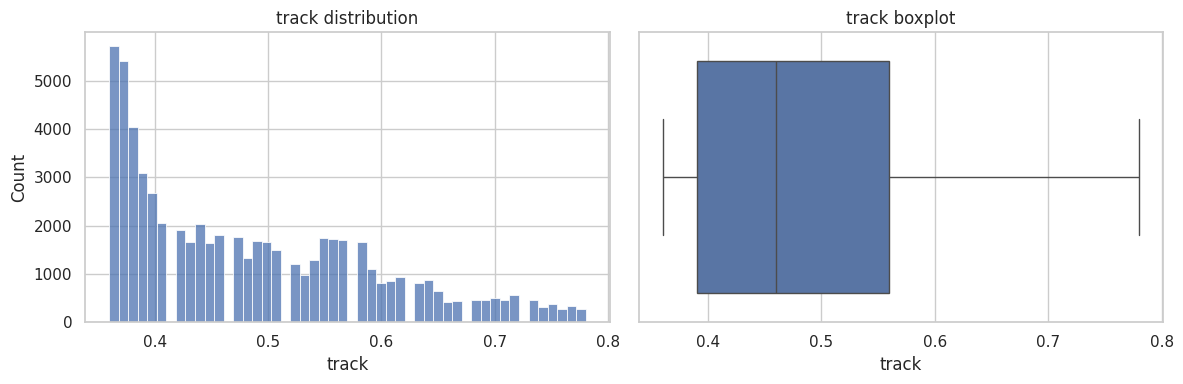

**Scan/track interpretation:** Variation, missingness, and extreme values are shown above. Their inclusion in future scoring should depend on demonstrated stability and relationship to a defined target, not on availability alone.

In [28]:
observation_geometry = [column for column in ['scan','track'] if column in df.columns]
for column in observation_geometry:
    values = pd.to_numeric(df[column], errors='coerce')
    display(pd.DataFrame({'metric':['count','missing','mean','median','std','min','p01','p99','max'], 'value':[values.notna().sum(),values.isna().sum(),values.mean(),values.median(),values.std(),values.min(),values.quantile(.01),values.quantile(.99),values.max()]}).assign(variable=column))
    extreme_values = df.loc[values >= values.quantile(.99), [column]].sort_values(column, ascending=False)
    print(f'{column} observations at or above the 99th percentile:', len(extreme_values)); display(extreme_values.head(20))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4)); sns.histplot(values.dropna(), bins=50, ax=axes[0]); axes[0].set_title(f'{column} distribution'); sns.boxplot(x=values.dropna(), ax=axes[1]); axes[1].set_title(f'{column} boxplot'); plt.tight_layout(); fig.savefig(FIG/f'{column}_distribution.png', dpi=150); plt.show()
display(Markdown('**Scan/track interpretation:** Variation, missingness, and extreme values are shown above. Their inclusion in future scoring should depend on demonstrated stability and relationship to a defined target, not on availability alone.'))

# 12. Feature Relationship Analysis

Cek korelasi antar variabel numerik, plus beberapa hubungan pairwise yang dipilih. Perlu diingat: korelasi itu sifatnya deskriptif doang — gak otomatis nunjukin hubungan sebab-akibat (causation).

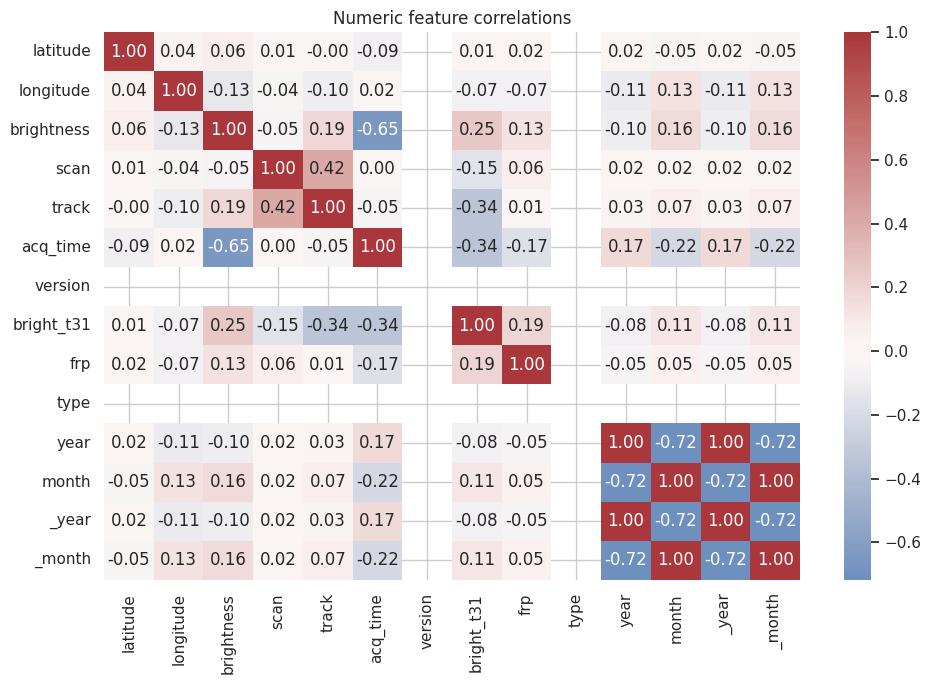

,latitude,longitude,brightness,scan,track,acq_time,version,bright_t31,frp,type,year,month,_year,_month
latitude,1.000,0.040,0.065,0.006,-0.002,-0.086,NaN,0.010,0.015,NaN,0.022,-0.045,0.022,-0.045
longitude,0.040,1.000,-0.132,-0.044,-0.096,0.017,NaN,-0.070,-0.069,NaN,-0.113,0.131,-0.113,0.131
brightness,0.065,-0.132,1.000,-0.048,0.186,-0.647,NaN,0.249,0.132,NaN,-0.100,0.159,-0.100,0.159
scan,0.006,-0.044,-0.048,1.000,0.418,0.000,NaN,-0.148,0.065,NaN,0.024,0.023,0.024,0.023
track,-0.002,-0.096,0.186,0.418,1.000,-0.050,NaN,-0.339,0.005,NaN,0.031,0.070,0.031,0.070
acq_time,-0.086,0.017,-0.647,0.000,-0.050,1.000,NaN,-0.339,-0.169,NaN,0.173,-0.216,0.173,-0.216
version,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bright_t31,0.010,-0.070,0.249,-0.148,-0.339,-0.339,NaN,1.000,0.193,NaN,-0.079,0.113,-0.079,0.113
frp,0.015,-0.069,0.132,0.065,0.005,-0.169,NaN,0.193,1.000,NaN,-0.050,0.050,-0.050,0.050
type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
corr=df.select_dtypes(include=np.number).corr()
if not corr.empty:
    plt.figure(figsize=(10,7)); sns.heatmap(corr,cmap='vlag',center=0,annot=True,fmt='.2f'); plt.title('Numeric feature correlations'); plt.tight_layout(); plt.savefig(FIG/'numeric_correlations.png',dpi=150); plt.show(); display(corr)

## 12.1–12.3 Thermal Feature Relationships

Cek hubungan FRP sama brightness & Bright_T31, sekaligus liat apakah variabel-variabel brightness ini redundant satu sama lain atau enggak. Perhitungan korelasi pakai seluruh data yang tersedia, tapi buat plot-nya mungkin pakai sample (yang reproducible) biar tetep kebaca jelas — gak numpuk banget di titik.

FRP vs Brightness: full-data Pearson correlation = 0.1319; n = 61,583


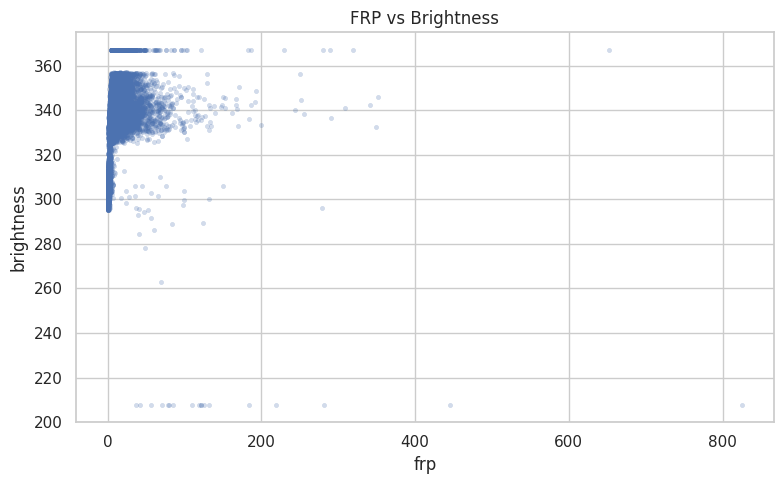

,count,mean,std,min,25%,50%,75%,max
frp,"61,583.000",10.570,17.424,0.090,3.580,6.140,11.430,954.790
brightness,"61,583.000",335.870,13.677,207.930,331.290,335.860,342.220,367.000


**Interpretasi FRP vs Brightness:** Korelasi Pearson pada seluruh data adalah **0.132**. Scatter plot ini menunjukkan sebaran yang cukup "berawan"/noisy, mengonfirmasi lemahnya korelasi linear -- meski ada pola kasar bahwa frp tinggi cenderung diikuti brightness yang juga lebih tinggi.

FRP vs Bright_T31: full-data Pearson correlation = 0.1928; n = 61,583


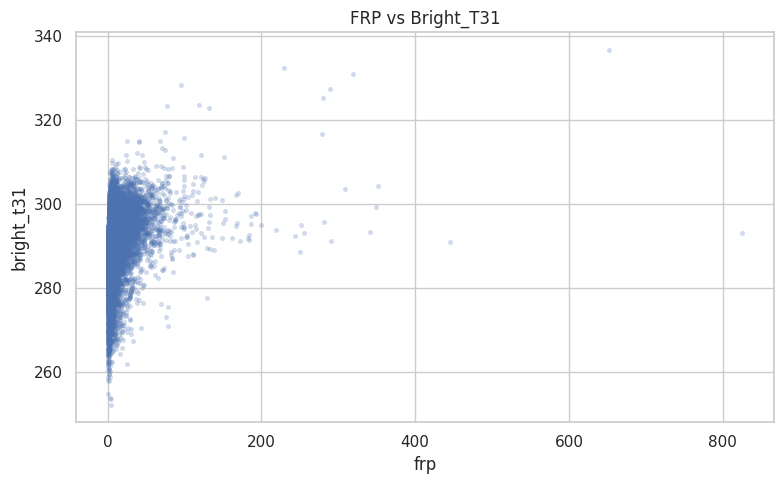

,count,mean,std,min,25%,50%,75%,max
frp,"61,583.000",10.570,17.424,0.090,3.580,6.140,11.430,954.790
bright_t31,"61,583.000",292.131,6.517,241.480,289.390,292.990,296.270,361.810


**Interpretasi FRP vs Bright_T31:** Korelasi Pearson pada seluruh data adalah **0.193**. Scatter plot ini menunjukkan sebaran yang cukup "berawan"/noisy, mengonfirmasi lemahnya korelasi linear -- meski ada pola kasar bahwa frp tinggi cenderung diikuti bright_t31 yang juga lebih tinggi.

Brightness vs Bright_T31: full-data Pearson correlation = 0.2491; n = 61,583


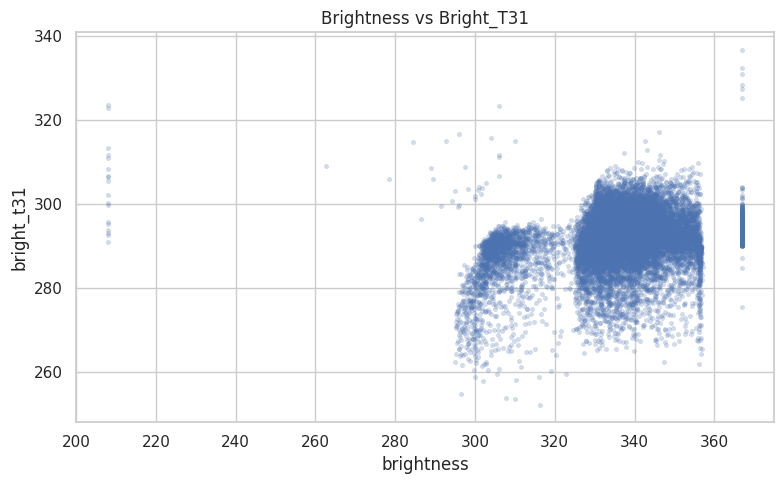

,count,mean,std,min,25%,50%,75%,max
brightness,"61,583.000",335.870,13.677,207.930,331.290,335.860,342.220,367.000
bright_t31,"61,583.000",292.131,6.517,241.480,289.390,292.990,296.270,361.810


**Interpretasi Brightness vs Bright_T31:** Korelasi Pearson pada seluruh data adalah **0.249**. Scatter plot ini menunjukkan sebaran yang cukup "berawan"/noisy, mengonfirmasi lemahnya korelasi linear -- meski ada pola kasar bahwa brightness tinggi cenderung diikuti bright_t31 yang juga lebih tinggi.

In [30]:
relationship_pairs = [(frp, brightness_column, 'FRP vs Brightness'), (frp, bright_t31_column, 'FRP vs Bright_T31'), (brightness_column, bright_t31_column, 'Brightness vs Bright_T31')]
for x_column, y_column, title in relationship_pairs:
    if x_column and y_column:
        pair = df[[x_column,y_column]].apply(pd.to_numeric, errors='coerce').dropna()
        correlation = pair[x_column].corr(pair[y_column])
        print(f'{title}: full-data Pearson correlation = {correlation:.4f}; n = {len(pair):,}')
        plot_pair = pair.sample(min(len(pair), 20000), random_state=42)
        fig_name = title.lower().replace(' ', '_').replace('/', '_') + '.png'
        plt.figure(figsize=(8,5)); sns.scatterplot(data=plot_pair, x=x_column, y=y_column, s=10, alpha=.25, edgecolor=None); plt.title(title); plt.tight_layout(); plt.savefig(FIG/fig_name, dpi=150); plt.show()
        display(pair.describe().T)
        if abs(correlation) < 0.4:
            strength_note = f'Scatter plot ini menunjukkan sebaran yang cukup "berawan"/noisy, mengonfirmasi lemahnya korelasi linear -- meski ada pola kasar bahwa {x_column} tinggi cenderung diikuti {y_column} yang juga lebih tinggi.'
        elif abs(correlation) < 0.7:
            strength_note = 'Scatter plot menunjukkan tren yang cukup terlihat meski masih tersebar, sesuai dengan kekuatan korelasinya.'
        else:
            strength_note = 'Scatter plot menunjukkan pola yang cukup rapat dan mendekati garis lurus, sesuai dengan korelasi yang kuat.'
        display(Markdown(f'**Interpretasi {title}:** Korelasi Pearson pada seluruh data adalah **{correlation:.3f}**. {strength_note}'))


## 12.4 FRP vs Confidence

Bandingin FRP di tiap kategori confidence pakai statistik grouped & boxplot. Confidence sengaja dibiarin sebagai kategori (bukan dipaksa jadi angka numerik sembarangan), karena urutan `low → nominal → high` itu bukan skala linear yang beneran merepresentasikan intensitas.

,count,mean,median,std,min,max
confidence,,,,,,
h,2320,18.371,13.360,19.225,4.190,338.020
l,1948,28.857,12.765,56.925,1.440,954.790
n,57315,9.633,5.820,13.655,0.090,550.260


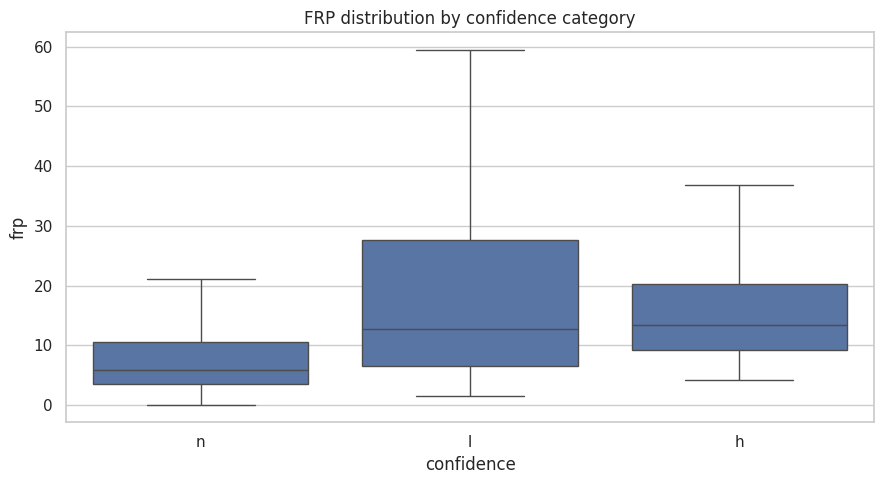

**FRP-confidence interpretation:** Category-level differences and boxplot overlap are more appropriate than a correlation unless a justified ordinal encoding is established.

In [31]:
if frp and conf:
    frp_confidence_relationship = df.groupby(conf, dropna=False)[frp].agg(['count','mean','median','std','min','max'])
    display(frp_confidence_relationship); frp_confidence_relationship.to_csv(TAB/'relationship_frp_confidence.csv')
    plt.figure(figsize=(9,5)); sns.boxplot(data=df, x=conf, y=frp, showfliers=False); plt.title('FRP distribution by confidence category'); plt.tight_layout(); plt.savefig(FIG/'relationship_frp_confidence.png', dpi=150); plt.show()
    display(Markdown('**FRP-confidence interpretation:** Category-level differences and boxplot overlap are more appropriate than a correlation unless a justified ordinal encoding is established.'))

## 12.5 FRP vs Day/Night

Bandingin mean, median, sama distribusi FRP antara observasi siang vs malam — dengan tetep sadar bahwa waktu observasi & kondisi deteksi bisa mempengaruhi angka yang tercatat, jadi gak bisa langsung dibaca sebagai "malam emang lebih kecil apinya".

,count,mean,median,std,min,max
daynight,,,,,,
D,54988,11.611,6.830,18.146,0.730,954.790
N,6595,1.887,1.270,2.231,0.090,38.300


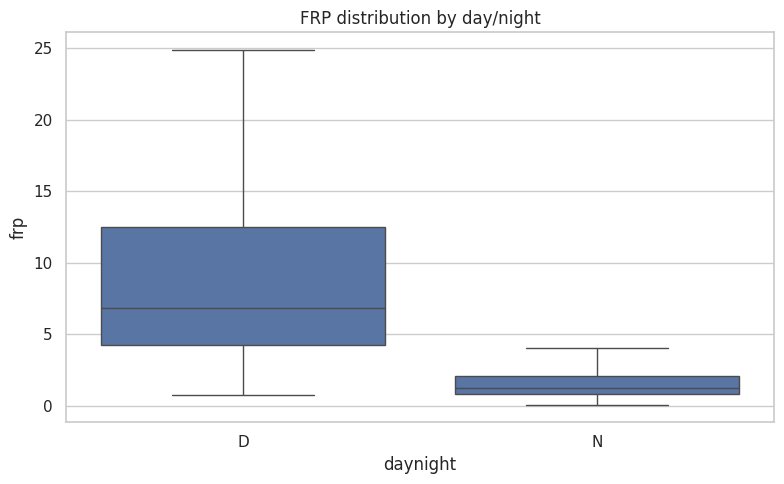

**Day/night intensity interpretation:** Differences in mean or median FRP describe detected thermal intensity by observation category. They do not establish that one period has more or fewer fires, because satellite observation characteristics may differ.

In [32]:
if frp and 'daynight' in df.columns:
    frp_daynight_relationship = df.groupby('daynight', dropna=False)[frp].agg(['count','mean','median','std','min','max']); display(frp_daynight_relationship); frp_daynight_relationship.to_csv(TAB/'relationship_frp_daynight.csv')
    plt.figure(figsize=(8,5)); sns.boxplot(data=df, x='daynight', y=frp, showfliers=False); plt.title('FRP distribution by day/night'); plt.tight_layout(); plt.savefig(FIG/'relationship_frp_daynight.png', dpi=150); plt.show()
    display(Markdown('**Day/night intensity interpretation:** Differences in mean or median FRP describe detected thermal intensity by observation category. They do not establish that one period has more or fewer fires, because satellite observation characteristics may differ.'))

# 13. Feature Suitability for Future Scoring

Evaluasi tiap variabel kandidat berdasarkan kriteria praktis: ketersediaannya gimana, seberapa banyak missing, gampang diinterpretasi gak, stabil gak dari waktu ke waktu, dan ada risiko leakage/observation bias gak. Ini murni penilaian kesiapan (readiness assessment) — **bukan** bikin model scoring beneran.

In [33]:
candidates=[c for c in [lat,lon,frp,conf,quality.get('scan'),quality.get('track')] if c]
suit=pd.DataFrame({'feature':candidates,'dtype':[str(df[c].dtype) for c in candidates],'missing_pct':[round(df[c].isna().mean()*100,2) for c in candidates],'unique_values':[df[c].nunique(dropna=True) for c in candidates]})
suit['initial_role']=suit['feature'].map(lambda c: 'intensity proxy' if c==frp else 'detection quality' if c==conf else 'location/geometry' if c in [lat,lon] else 'observation geometry')
display(suit); suit.to_csv(TAB/'feature_suitability_inventory.csv',index=False)
display(Markdown('**Suitability interpretation:** FRP can support intensity-oriented features, confidence can support detection-quality filtering or weighting, and coordinates can support location-derived features. Before scoring, validate temporal completeness, account for partial 2026 coverage, examine observation bias, and define the target concept explicitly.'))

,feature,dtype,missing_pct,unique_values,initial_role
0,latitude,float64,0.000,57283,location/geometry
1,longitude,float64,0.000,57874,location/geometry
2,frp,float64,0.000,5113,intensity proxy
3,confidence,str,0.000,3,detection quality
4,scan,float64,0.000,49,observation geometry
5,track,float64,0.000,43,observation geometry


**Suitability interpretation:** FRP can support intensity-oriented features, confidence can support detection-quality filtering or weighting, and coordinates can support location-derived features. Before scoring, validate temporal completeness, account for partial 2026 coverage, examine observation bias, and define the target concept explicitly.

## Feature Evaluation

Ini cuma assessment kelayakan doang. Belum ada sistem scoring, bobot final, normalisasi, atau agregasi fitur apapun yang dibikin di notebook ini — itu semua di luar scope EDA.

In [34]:
feature_roles = {'frp':('Fire intensity','Robust summary; log or percentile transformation may be needed','High missingness or extreme tail; detected radiant power is not total severity'), 'confidence':('Detection reliability','Categorical distribution and filtering/weighting candidate','Categorical; meaning depends on FIRMS definition'), 'brightness':('Thermal signal','Continuous thermal feature','May be redundant with FRP or Bright_T31; inspect skew and scale'), 'bright_t31':('Background thermal context','Contextual thermal feature','Possible redundancy; interpretation requires thermal context'), 'daynight':('Observation context','Stratification or categorical context','Sensor/observation bias; not a direct severity measure'), 'scan':('Pixel characteristic','Observation-geometry/context feature','Interpretation required; may reflect footprint/geometry'), 'track':('Pixel characteristic','Observation-geometry/context feature','Interpretation required; may reflect footprint/geometry'), 'latitude':('Spatial information','Aggregated spatial or regional feature','Raw coordinate is not a severity measure'), 'longitude':('Spatial information','Aggregated spatial or regional feature','Raw coordinate is not a severity measure')}
evaluation_rows = []
for feature, (role, use, limitation) in feature_roles.items():
    present = feature in df.columns
    if present:
        values = df[feature]
        variation = f'{values.nunique(dropna=True)} unique; std={pd.to_numeric(values, errors="coerce").std():.3f}' if pd.api.types.is_numeric_dtype(values) else f'{values.nunique(dropna=True)} categories'
        missing_quality = f'{values.isna().mean()*100:.2f}% missing'
        redundancy = 'Assess with correlation/plots' if feature in ['frp','brightness','bright_t31'] else 'Not directly assessed'
        meaningful = 'Yes, observed variation' if values.nunique(dropna=True) > 1 else 'No meaningful variation'
        transform = 'Likely' if feature == 'frp' else 'Possibly' if feature in ['brightness','bright_t31','scan','track'] else 'Not necessarily'
    else:
        variation, missing_quality, redundancy, meaningful, transform = 'Not available', 'Not available', 'Not assessed', 'No', 'Not applicable'
    evaluation_rows.append({'Feature':feature.replace('_',' ').title(),'Potential Role':role,'Variation':variation,'Data Quality':missing_quality,'Limitation':limitation,'Potential Use':use,'Meaningful variation?':meaningful,'Redundant?':redundancy,'Transformation needed?':transform})
feature_evaluation = pd.DataFrame(evaluation_rows)
display(feature_evaluation)
feature_evaluation.to_csv(TAB/'feature_evaluation.csv', index=False)
display(Markdown('**Feature suitability conclusion:** Candidate usefulness is conditional on the observed variation, missingness, redundancy checks, and interpretation limitations shown above. FRP may require robust transformation, categorical/context variables should not be treated as direct severity measures, and latitude/longitude require aggregation. No final weights or score are assigned.'))

,Feature,Potential Role,Variation,Data Quality,Limitation,Potential Use,Meaningful variation?,Redundant?,Transformation needed?
0,Frp,Fire intensity,5113 unique; std=17.424,0.00% missing,High missingness or extreme tail; detected rad...,Robust summary; log or percentile transformati...,"Yes, observed variation",Assess with correlation/plots,Likely
1,Confidence,Detection reliability,3 categories,0.00% missing,Categorical; meaning depends on FIRMS definition,Categorical distribution and filtering/weighti...,"Yes, observed variation",Not directly assessed,Not necessarily
2,Brightness,Thermal signal,5462 unique; std=13.677,0.00% missing,May be redundant with FRP or Bright_T31; inspe...,Continuous thermal feature,"Yes, observed variation",Assess with correlation/plots,Possibly
3,Bright T31,Background thermal context,4106 unique; std=6.517,0.00% missing,Possible redundancy; interpretation requires t...,Contextual thermal feature,"Yes, observed variation",Assess with correlation/plots,Possibly
4,Daynight,Observation context,2 categories,0.00% missing,Sensor/observation bias; not a direct severity...,Stratification or categorical context,"Yes, observed variation",Not directly assessed,Not necessarily
5,Scan,Pixel characteristic,49 unique; std=0.087,0.00% missing,Interpretation required; may reflect footprint...,Observation-geometry/context feature,"Yes, observed variation",Not directly assessed,Possibly
6,Track,Pixel characteristic,43 unique; std=0.109,0.00% missing,Interpretation required; may reflect footprint...,Observation-geometry/context feature,"Yes, observed variation",Not directly assessed,Possibly
7,Latitude,Spatial information,57283 unique; std=1.437,0.00% missing,Raw coordinate is not a severity measure,Aggregated spatial or regional feature,"Yes, observed variation",Not directly assessed,Not necessarily
8,Longitude,Spatial information,57874 unique; std=2.845,0.00% missing,Raw coordinate is not a severity measure,Aggregated spatial or regional feature,"Yes, observed variation",Not directly assessed,Not necessarily


**Feature suitability conclusion:** Candidate usefulness is conditional on the observed variation, missingness, redundancy checks, and interpretation limitations shown above. FRP may require robust transformation, categorical/context variables should not be treated as direct severity measures, and latitude/longitude require aggregation. No final weights or score are assigned.

# 14. Final Insights & Conclusions

Bagian ini merangkum **hanya** temuan-temuan yang beneran dihasilin dari cell-cell yang udah dieksekusi di atas — gak nambah klaim baru yang gak ada dasarnya. Dataset ini cocok buat lanjut ke tahap eksplorasi berikutnya, dengan catatan kesimpulan yang diambil tetap kondisional terhadap coverage data & limitasi sistem deteksinya. Inferensi tingkat provinsi, spatial join, machine learning, sampai sistem scoring final sengaja **belum** dikerjain di sini — nunggu data pendukung & target yang jelas dulu.

In [35]:
if date_col:
    latest=int(df['_year'].max()); latest_end=df.loc[df['_year']==latest,'_datetime'].max();
    display(Markdown(f'''**Evidence-based summary**

- Observations: **{len(df):,}**; date range: **{df['_datetime'].min().date()} to {df['_datetime'].max().date()}**.
- Latest observed year: **{latest}**, ending **{latest_end.date()}**; treat it as partial unless the coverage table demonstrates otherwise.
- Exact duplicates: **{df.duplicated().sum():,}**; unparseable dates: **{df['_datetime'].isna().sum():,}**.
- The temporal, spatial, intensity, confidence, and feature-inventory outputs above are the basis for all conclusions.

**Decision:** Proceed with careful downstream feature engineering only after documenting coverage gaps, detection bias, and the intended scoring target; do not interpret these detections as province totals or complete fire events.'''))

**Evidence-based summary**

- Observations: **61,583**; date range: **2024-08-01 to 2026-05-31**.
- Latest observed year: **2026**, ending **2026-05-31**; treat it as partial unless the coverage table demonstrates otherwise.
- Exact duplicates: **0**; unparseable dates: **0**.
- The temporal, spatial, intensity, confidence, and feature-inventory outputs above are the basis for all conclusions.

**Decision:** Proceed with careful downstream feature engineering only after documenting coverage gaps, detection bias, and the intended scoring target; do not interpret these detections as province totals or complete fire events.

## Comprehensive Results-Based Summary

Summary di bawah ini digenerate dari output analisis yang udah dieksekusi di atas. Sengaja dipisahin jelas antara "observasi" (apa yang keliatan di data) vs "interpretasi" (apa maknanya), tahun-tahun yang parsial ditandain, dan **gak** ada inferensi tingkat provinsi, hubungan sebab-akibat, atau severity kebakaran yang ditarik cuma dari jumlah deteksi doang.

In [36]:
if date_col:
    missing_focus = missing_summary[missing_summary['Column name'].isin(['latitude','longitude','acq_date','frp','confidence','daynight'])]
    year_text = ', '.join(str(year) for year in incomplete_years) if incomplete_years else 'none identified by the observed end month'
    peak_month_name = month_summary.loc[month_summary['total_hotspots'].idxmax(), 'month_name'] if 'month_summary' in globals() else 'not available'
    display(Markdown(f'''### Data quality
- Total records: **{len(df):,}**; exact duplicate rows: **{int(df.duplicated().sum()):,}**; unparseable dates: **{int(df['_datetime'].isna().sum()):,}**.
- Focused missingness is shown in the saved missing-value table and above; rows were not silently removed.
- Coordinate validity and suspicious records are documented in `coordinate_validation.csv`; no province assignment was performed.
- FRP extremes and categorical irregularities are reported for review, not automatically removed or recoded.

### Temporal coverage and patterns
- Observed date range: **{df['_datetime'].min().date()} to {df['_datetime'].max().date()}**.
- Dates with no detections inside that span: **{len(temporal_gaps):,}**; empty year-month combinations: **{len(missing_months):,}**.
- Incomplete years based on observed end month: **{year_text}**. Partial-year totals must not be directly compared with complete years.
- Aggregate peak month: **{peak_month_name}**. Whether seasonality is consistent must be judged from the year-separated monthly table, not assumed from the aggregate.

### Spatial patterns
- Coordinate histograms, scatter, and hexbin show the observed footprint and density concentrations only. No province names are assigned. Dense cells may reflect repeated detections and observation opportunity as well as activity.

### Fire intensity and confidence
- FRP is summarized with median and percentiles because its distribution may be skewed; high-frequency periods are not automatically high-severity periods.
- Confidence proportions, FRP/thermal comparisons, and the all-records versus excluded-low-confidence scenarios are reported in the saved tables. Low-confidence observations remain in the source analysis.

### Relationships and future scoring readiness
- Full-data correlations and grouped comparisons identify potentially related thermal variables; correlation does not establish causality.
- FRP is generally the strongest intensity-oriented candidate but may need robust transformation. Brightness and Bright_T31 are potential candidates subject to redundancy checks. Confidence and day/night are contextual/detection-quality variables. Scan and track are weak-to-potential candidates until their interpretation and target relationship are established. Latitude/longitude are contextual spatial variables requiring aggregation.
- No final weights, normalization, risk model, or severity score was created.'''))

### Data quality
- Total records: **61,583**; exact duplicate rows: **0**; unparseable dates: **0**.
- Focused missingness is shown in the saved missing-value table and above; rows were not silently removed.
- Coordinate validity and suspicious records are documented in `coordinate_validation.csv`; no province assignment was performed.
- FRP extremes and categorical irregularities are reported for review, not automatically removed or recoded.

### Temporal coverage and patterns
- Observed date range: **2024-08-01 to 2026-05-31**.
- Dates with no detections inside that span: **40**; empty year-month combinations: **14**.
- Incomplete years based on observed end month: **2026**. Partial-year totals must not be directly compared with complete years.
- Aggregate peak month: **September**. Whether seasonality is consistent must be judged from the year-separated monthly table, not assumed from the aggregate.

### Spatial patterns
- Coordinate histograms, scatter, and hexbin show the observed footprint and density concentrations only. No province names are assigned. Dense cells may reflect repeated detections and observation opportunity as well as activity.

### Fire intensity and confidence
- FRP is summarized with median and percentiles because its distribution may be skewed; high-frequency periods are not automatically high-severity periods.
- Confidence proportions, FRP/thermal comparisons, and the all-records versus excluded-low-confidence scenarios are reported in the saved tables. Low-confidence observations remain in the source analysis.

### Relationships and future scoring readiness
- Full-data correlations and grouped comparisons identify potentially related thermal variables; correlation does not establish causality.
- FRP is generally the strongest intensity-oriented candidate but may need robust transformation. Brightness and Bright_T31 are potential candidates subject to redundancy checks. Confidence and day/night are contextual/detection-quality variables. Scan and track are weak-to-potential candidates until their interpretation and target relationship are established. Latitude/longitude are contextual spatial variables requiring aggregation.
- No final weights, normalization, risk model, or severity score was created.